In [1]:
# =============================================================================
# Papyrus Data Classification
# =============================================================================
# Classify molecules from papyrus filtered data using the MolecularTypeClassifier
# =============================================================================

import sys
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import joblib
import re
import ast

# Add mol_utils to path
sys.path.insert(0, "/home/ec2-user/mol-utils/src")

from rdkit import Chem
from mol_utils import MolecularClassifier

print(f"Python: {sys.executable}")

# Configuration
work_dir = "/fsx/amira/papyrus_target_prioritization"
model_dir = "/fsx/alex/MolecularTypeClassifier-1/scratch"

# Initialize classifier
classifier = MolecularClassifier()
print("MolecularClassifier loaded successfully")


Python: /home/ec2-user/MolecularTypeClassifier/.pixi/envs/default/bin/python
MolecularClassifier loaded successfully


In [2]:
# =============================================================================
# Load Saved Papyrus Data
# =============================================================================

input_file = f"{work_dir}/papyrus_filtered.tsv.xz"
print(f"Loading data from: {input_file}")

papyrus_df = pd.read_csv(input_file, sep='\t', compression='xz')
print(f"Loaded {len(papyrus_df):,} records")
print(f"Columns: {papyrus_df.columns.tolist()}")
print(f"\nUnique SMILES: {papyrus_df['SMILES'].nunique():,}")
papyrus_df.head()


Loading data from: /fsx/amira/papyrus_target_prioritization/papyrus_filtered.tsv.xz


/tmp/ipykernel_2414020/359696166.py:8: DtypeWarning: Columns (16,17,18,19,20,21,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  papyrus_df = pd.read_csv(input_file, sep='\t', compression='xz')


Loaded 2,395,676 records
Columns: ['Activity_ID', 'Quality', 'source', 'CID', 'SMILES', 'connectivity', 'InChIKey', 'InChI', 'InChI_AuxInfo', 'target_id', 'accession', 'Protein_Type', 'AID', 'doc_id', 'Year', 'all_doc_ids', 'all_years', 'type_IC50', 'type_EC50', 'type_KD', 'type_Ki', 'type_other', 'Activity_class', 'relation', 'pchembl_value', 'pchembl_value_Mean', 'pchembl_value_StdDev', 'pchembl_value_SEM', 'pchembl_value_N', 'pchembl_value_Median', 'pchembl_value_MAD', 'Gene']

Unique SMILES: 454,776


,Activity_ID,Quality,source,CID,SMILES,connectivity,InChIKey,InChI,InChI_AuxInfo,target_id,...,Activity_class,relation,pchembl_value,pchembl_value_Mean,pchembl_value_StdDev,pchembl_value_SEM,pchembl_value_N,pchembl_value_Median,pchembl_value_MAD,Gene
0,AAABHMIRDIOYOK_on_P43220_WT,High,ExCAPE-DB,3147229,Cn1cc([N+](=O)[O-])c(C(=O)Nc2ccc3[nH]c(-c4cccc...,AAABHMIRDIOYOK,AAABHMIRDIOYOK-UHFFFAOYSA-N,InChI=1S/C18H14N6O3/c1-23-10-15(24(26)27)16(22...,"""AuxInfo=1/1/N:1,21,20,22,19,23,13,14,26,3,18,...",P43220_WT,...,NaN,=,4.950,4.950,0.000,0.000,1.0,4.95,0.0,GLP1R
1,AAAHTCZONLHYSA_on_P09619_WT,Medium,ChEMBL30,CHEMBL474208,Nc1ccccc1NC(=O)c1ccc(C(=O)Nc2cc(Nc3ncc(-c4cccn...,AAAHTCZONLHYSA,AAAHTCZONLHYSA-UHFFFAOYSA-N,InChI=1S/C26H20N6O2S2/c27-19-8-1-2-9-20(19)32-...,"""AuxInfo=1/1/N:4,5,34,28,27,35,33,3,6,13,12,29...",P09619_WT,...,NaN,=,4.550,4.550,0.000,0.000,1.0,4.55,0.0,PDGFRB
2,AAAHTCZONLHYSA_on_P35968_WT,Medium,ChEMBL30,CHEMBL474208,Nc1ccccc1NC(=O)c1ccc(C(=O)Nc2cc(Nc3ncc(-c4cccn...,AAAHTCZONLHYSA,AAAHTCZONLHYSA-UHFFFAOYSA-N,InChI=1S/C26H20N6O2S2/c27-19-8-1-2-9-20(19)32-...,"""AuxInfo=1/1/N:4,5,34,28,27,35,33,3,6,13,12,29...",P35968_WT,...,NaN,=,4.920,4.920,0.000,0.000,1.0,4.92,0.0,KDR/VEGFR2
3,AAAOTGDHZDZLFN_on_P30968_WT,High,ChEMBL30;ChEMBL30;ExCAPE-DB,CHEMBL1800663;CHEMBL1800663;53388960,CONC(=O)Nc1ccc(-c2c(CN(C)CCc3ccccn3)c3c(s2)n(C...,AAAOTGDHZDZLFN,AAAOTGDHZDZLFN-UHFFFAOYSA-N,InChI=1S/C36H32F2N6O4S/c1-42(20-18-24-9-6-7-19...,"""AuxInfo=1/1/N:15,1,43,42,44,20,21,33,19,41,45...",P30968_WT,...,NaN,=,10.150; 10.150; 10.155,10.152,0.002,0.002,3.0,10.15,0.0,GNRHR
4,AAAXBDFZRXKRPL_on_P35968_WT,Medium,ChEMBL30,CHEMBL571278,C#Cc1cccc(Nc2nccc3c2ccc(C)c3Nc2ncccc2-c2ncnc(N...,AAAXBDFZRXKRPL,AAAXBDFZRXKRPL-UHFFFAOYSA-N,InChI=1S/C28H23N7/c1-4-19-7-5-8-20(15-19)34-27...,"""AuxInfo=1/1/N:1,18,33,2,5,24,4,6,25,16,15,12,...",P35968_WT,...,NaN,=,6.380,6.380,0.000,0.000,1.0,6.38,0.0,KDR/VEGFR2


In [3]:
# =============================================================================
# Feature Extraction Functions (using MolecularClassifier)
# =============================================================================

def mol_from_smiles(smiles: str):
    """Safe RDKit SMILES to Mol conversion."""
    if not isinstance(smiles, str) or not smiles.strip():
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        try:
            mol = Chem.MolFromSmiles(smiles, sanitize=False)
            if mol is not None:
                Chem.SanitizeMol(mol)
        except Exception:
            return None
    return mol


def parse_feature_string(feature_str) -> dict:
    """Parse MolecularFeatures string to dict."""
    if not isinstance(feature_str, str) or not feature_str.strip():
        return {}
    
    s = feature_str.strip()
    if s.startswith("MolecularFeatures(") and s.endswith(")"):
        s = s[len("MolecularFeatures("):-1]
    
    # Extract pattern_counts first
    pattern_dict = {}
    m = re.search(r"pattern_counts\s*=\s*(\{.*\})", s)
    if m:
        pattern_text = m.group(1)
        s = s[:m.start()].rstrip().rstrip(",").rstrip()
        try:
            pattern_dict = ast.literal_eval(pattern_text)
        except Exception:
            pattern_dict = {}
    
    # Parse remaining k=v pairs
    features = {}
    for kv in re.split(r"\s*,\s*", s):
        if "=" not in kv:
            continue
        k, v = kv.split("=", 1)
        k = k.strip()
        v = v.strip()
        try:
            if re.fullmatch(r"[-+]?(?:\d+\.\d*|\d*\.\d+)(?:[eE][-+]?\d+)?", v):
                v = float(v)
            elif re.fullmatch(r"[-+]?\d+", v):
                v = int(v)
        except Exception:
            pass
        features[k] = v
    
    # Add pattern_counts as separate columns
    for pk, pv in pattern_dict.items():
        features[f"pattern_{pk}"] = pv
    
    return features


def extract_features_for_smiles(smiles: str) -> dict:
    """Extract features for a single SMILES using MolecularClassifier."""
    mol = mol_from_smiles(smiles)
    if mol is None:
        return {}
    
    try:
        feats = classifier.extract_features(mol)
        # Convert to dict
        if isinstance(feats, dict):
            return feats
        if isinstance(feats, pd.Series):
            return feats.to_dict()
        # If it's a MolecularFeatures object, convert to string and parse
        feat_str = str(feats)
        return parse_feature_string(feat_str)
    except Exception:
        return {}


def featurize_smiles_batch(smiles_list, show_progress=True):
    """Extract features for a list of SMILES strings."""
    iterator = tqdm(smiles_list, desc="Extracting features") if show_progress else smiles_list
    
    features_list = []
    for smi in iterator:
        feats = extract_features_for_smiles(smi)
        features_list.append(feats)
    
    return pd.DataFrame(features_list)

print("Feature extraction functions defined (using MolecularClassifier).")


Feature extraction functions defined (using MolecularClassifier).


In [4]:
# =============================================================================
# Extract Features from Unique SMILES
# =============================================================================

# Get unique SMILES to avoid redundant computation
unique_smiles = papyrus_df['SMILES'].dropna().unique()
print(f"Extracting features for {len(unique_smiles):,} unique SMILES...")

# Extract features
features_df = featurize_smiles_batch(unique_smiles)

# Create mapping from SMILES to features
smiles_to_idx = {smi: i for i, smi in enumerate(unique_smiles)}
print(f"\nFeatures extracted: {features_df.shape[1]} columns")
print(f"Feature columns: {features_df.columns.tolist()}")
features_df.head()


Extracting features for 449,020 unique SMILES...


Extracting features:   0%|          | 0/449020 [00:00<?, ?it/s]


Features extracted: 51 columns
Feature columns: ['molecular_weight', 'heavy_atom_count', 'ring_count', 'largest_ring_size', 'percent_heavy_in_rings', 'rotatable_bonds', 'peptide_bond_count', 'peptide_backbone_length', 'nucleotide_count', 'glycosidic_bond_count', 'aromatic_ring_count', 'pattern_PYRIMIDINE_BASE', 'pattern_PEPTIDE_BOND', 'pattern_AA_GLYCINE', 'pattern_ALPHA_AMINO_ACID', 'pattern_BETA_AMINO_ACID', 'pattern_PEPTIDE_BACKBONE', 'pattern_FURANOSE', 'pattern_AA_PHENYLALANINE', 'pattern_AA_PROLINE', 'pattern_AA_TRYPTOPHAN', 'pattern_AA_TYROSINE', 'pattern_N_METHYL_PEPTIDE', 'pattern_PYRANOSE', 'pattern_AA_ISOLEUCINE', 'pattern_MACROCYCLE_12', 'pattern_MACROCYCLE_15', 'pattern_NUCLEOBASE_ADENINE', 'pattern_AA_LEUCINE', 'pattern_AA_VALINE', 'pattern_AA_LYSINE', 'pattern_AA_ALANINE', 'pattern_AA_ASPARTATE', 'pattern_AA_SERINE', 'pattern_GLYCOSIDIC_BOND', 'pattern_AA_CYSTEINE', 'pattern_DISULFIDE', 'pattern_AA_GLUTAMATE', 'pattern_AA_METHIONINE', 'pattern_AA_THREONINE', 'pattern_AA

,molecular_weight,heavy_atom_count,ring_count,largest_ring_size,percent_heavy_in_rings,rotatable_bonds,peptide_bond_count,peptide_backbone_length,nucleotide_count,glycosidic_bond_count,...,pattern_AA_ASPARAGINE,pattern_GALACTOSE,pattern_GLUCOSE,pattern_MANNOSE,pattern_NUCLEOBASE_CYTOSINE,pattern_PHOSPHATE_BACKBONE,pattern_NUCLEOBASE_URACIL,pattern_NUCLEOBASE_THYMINE,pattern_PURINE_BASE,pattern_AA_HISTIDINE
0,362.349,27,4,6,74.074074,4,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,512.620,36,5,6,77.777778,7,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,682.753,49,6,6,67.346939,11,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,457.541,35,5,6,80.000000,6,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,481.145,25,1,6,24.000000,8,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# =============================================================================
# Load or Train Classification Model
# =============================================================================

model_path = f"{model_dir}/molecular_classifier_model.joblib"
encoder_path = f"{model_dir}/molecular_classifier_label_encoder.joblib"

if os.path.exists(model_path) and os.path.exists(encoder_path):
    print("Loading pre-trained model...")
    clf = joblib.load(model_path)
    label_encoder = joblib.load(encoder_path)
    print(f"Model loaded from {model_path}")
    print(f"Classes: {label_encoder.classes_}")
else:
    print("No pre-trained model found. Training new model...")
    print("Please run RandomForest_molecularClassification.ipynb first to train and save the model.")
    print(f"Expected model path: {model_path}")
    clf = None
    label_encoder = None


Loading pre-trained model...
Model loaded from /fsx/alex/MolecularTypeClassifier-1/scratch/molecular_classifier_model.joblib
Classes: ['can_peptide' 'sm' 'unwanted']


In [6]:
# =============================================================================
# Classify Molecules
# =============================================================================

if clf is not None and label_encoder is not None:
    print("Classifying molecules...")
    
    # The 52 feature columns expected by the model (from training data)
    MODEL_FEATURE_COLUMNS = [
        'molecular_weight', 'heavy_atom_count', 'ring_count', 'largest_ring_size',
        'percent_heavy_in_rings', 'rotatable_bonds', 'peptide_bond_count',
        'peptide_backbone_length', 'nucleotide_count', 'glycosidic_bond_count',
        'aromatic_ring_count', 'pattern_AA_ASPARAGINE', 'pattern_AA_ASPARTATE',
        'pattern_AA_GLUTAMATE', 'pattern_AA_GLYCINE', 'pattern_AA_ISOLEUCINE',
        'pattern_AA_LEUCINE', 'pattern_AA_PHENYLALANINE', 'pattern_AA_PROLINE',
        'pattern_AA_TYROSINE', 'pattern_ALPHA_AMINO_ACID', 'pattern_BETA_AMINO_ACID',
        'pattern_PEPTIDE_BACKBONE', 'pattern_PEPTIDE_BOND', 'pattern_AA_HISTIDINE',
        'pattern_AA_SERINE', 'pattern_AA_TRYPTOPHAN', 'pattern_AA_ALANINE',
        'pattern_AA_VALINE', 'pattern_AA_CYSTEINE', 'pattern_AA_GLUTAMINE',
        'pattern_DISULFIDE', 'pattern_MACROCYCLE_12', 'pattern_MACROCYCLE_15',
        'pattern_N_METHYL_PEPTIDE', 'pattern_PHOSPHATE_BACKBONE', 'pattern_FURANOSE',
        'pattern_PYRIMIDINE_BASE', 'pattern_NUCLEOBASE_ADENINE', 'pattern_AA_LYSINE',
        'pattern_AA_METHIONINE', 'pattern_AA_THREONINE', 'pattern_GLYCOSIDIC_BOND',
        'pattern_PYRANOSE', 'pattern_NUCLEOBASE_URACIL', 'pattern_GALACTOSE',
        'pattern_GLUCOSE', 'pattern_MANNOSE', 'pattern_NUCLEOBASE_GUANINE',
        'pattern_NUCLEOBASE_THYMINE', 'pattern_NUCLEOBASE_CYTOSINE', 'pattern_DEOXYRIBOSE'
    ]
    
    print(f"Model expects {len(MODEL_FEATURE_COLUMNS)} features")
    print(f"Features extracted: {features_df.shape[1]} columns")
    
    # Reindex to match model's expected features (fill missing with 0)
    X_unique = features_df.reindex(columns=MODEL_FEATURE_COLUMNS, fill_value=0).values
    
    # Handle NaN values
    X_unique = np.nan_to_num(X_unique, nan=0.0).astype(np.float32)
    
    print(f"Feature matrix shape: {X_unique.shape}")
    
    # Predict classes for unique SMILES
    predictions_unique = clf.predict(X_unique)
    pred_labels_unique = label_encoder.inverse_transform(predictions_unique)
    
    # Create mapping from SMILES to prediction
    smiles_to_pred = dict(zip(unique_smiles, pred_labels_unique))
    
    # Map predictions back to full dataframe
    papyrus_df['predicted_mol_class'] = papyrus_df['SMILES'].map(smiles_to_pred)
    
    print(f"\nClassification complete!")
    print(f"\nClass distribution:")
    print(papyrus_df['predicted_mol_class'].value_counts())
else:
    print("Model not available. Cannot classify molecules.")


Classifying molecules...
Model expects 52 features
Features extracted: 51 columns
Feature matrix shape: (449020, 52)

Classification complete!

Class distribution:
predicted_mol_class
sm             2354016
can_peptide       4533
unwanted          1668
Name: count, dtype: int64


In [7]:
# =============================================================================
# Save Classified Data
# =============================================================================

if 'predicted_mol_class' in papyrus_df.columns:
    print(f"Saving classified data to {work_dir}...")
    
    # Save full classified data with ALL columns
    output_classified = f"{work_dir}/papyrus_classified.tsv.xz"
    papyrus_df.to_csv(output_classified, sep='\t', index=False, compression='xz')
    print(f"  Saved {len(papyrus_df):,} records ({len(papyrus_df.columns)} columns) to {output_classified}")
    
    # Save summary by target and molecule class
    summary_by_target_class = papyrus_df.groupby(['accession', 'Gene', 'predicted_mol_class']).agg({
        'SMILES': 'nunique'
    }).reset_index()
    summary_by_target_class.columns = ['UniProtID', 'Gene', 'MoleculeClass', 'Count']
    output_summary = f"{work_dir}/papyrus_classified_summary.tsv"
    summary_by_target_class.to_csv(output_summary, sep='\t', index=False)
    print(f"  Saved summary to {output_summary}")
    
    # Pivot table: targets x molecule classes
    pivot = summary_by_target_class.pivot_table(
        index=['UniProtID', 'Gene'], 
        columns='MoleculeClass', 
        values='Count', 
        fill_value=0
    )
    pivot_output = f"{work_dir}/papyrus_target_class_pivot.tsv"
    pivot.to_csv(pivot_output, sep='\t')
    print(f"  Saved pivot table to {pivot_output}")
    
    # Save small molecules only
    sm_classes = ['sm', 'nat_prod']
    sm_df = papyrus_df[papyrus_df['predicted_mol_class'].isin(sm_classes)]
    if len(sm_df) > 0:
        output_sm = f"{work_dir}/papyrus_small_molecules.tsv.xz"
        sm_df.to_csv(output_sm, sep='\t', index=False, compression='xz')
        print(f"  Saved {len(sm_df):,} small molecules to {output_sm}")
    
    # Save peptides only
    peptide_classes = ['can_peptides', 'noncan_peptides', 'cyclic_pep_circle', 'cyclic_pep_lariat']
    peptide_df = papyrus_df[papyrus_df['predicted_mol_class'].isin(peptide_classes)]
    if len(peptide_df) > 0:
        output_pep = f"{work_dir}/papyrus_peptides.tsv.xz"
        peptide_df.to_csv(output_pep, sep='\t', index=False, compression='xz')
        print(f"  Saved {len(peptide_df):,} peptides to {output_pep}")
    
    print("\nDone!")
else:
    print("No classification results to save.")


Saving classified data to /fsx/amira/papyrus_target_prioritization...
  Saved 2,360,217 records (34 columns) to /fsx/amira/papyrus_target_prioritization/papyrus_classified.tsv.xz
  Saved summary to /fsx/amira/papyrus_target_prioritization/papyrus_classified_summary.tsv
  Saved pivot table to /fsx/amira/papyrus_target_prioritization/papyrus_target_class_pivot.tsv
  Saved 2,354,016 small molecules to /fsx/amira/papyrus_target_prioritization/papyrus_small_molecules.tsv.xz

Done!


In [8]:
# =============================================================================
# Classification Summary by Target
# =============================================================================

if 'predicted_mol_class' in papyrus_df.columns:
    print("Classification summary by target:")
    print("=" * 80)
    
    # Show pivot table
    display(pivot)
    
    print("\n" + "=" * 80)
    print("Top targets by total molecule count:")
    target_totals = papyrus_df.groupby(['accession', 'Gene']).agg({
        'SMILES': 'nunique'
    }).reset_index()
    target_totals.columns = ['UniProtID', 'Gene', 'Total_Molecules']
    target_totals = target_totals.sort_values('Total_Molecules', ascending=False)
    display(target_totals.head(20))


Classification summary by target:


,MoleculeClass,can_peptide,sm,unwanted
UniProtID,Gene,,,
P00734,F2,522.0,216353.0,119.0
P00747,PLG,10.0,1178.0,12.0
P03951,F11,496.0,215388.0,97.0
P03952,KLKB1,5.0,1145.0,9.0
P04578,env (HIV-1),0.0,6.0,1.0
P04585,Gag-Pol (HIV-1),0.0,225.0,0.0
P05106,ITGB3 (Fibrinogen gpIIIa),51.0,2420.0,223.0
P08514,Integrin alpha Iib,50.0,1648.0,153.0
P08709,F7,8.0,1052.0,0.0



Top targets by total molecule count:


,UniProtID,Gene,Total_Molecules
40,Q03431,PTH1R,386607
24,P32245,MC4R,346334
16,P30559,OXTR,316068
30,P37288,AVPR1A,315714
33,P43220,GLP1R,296775
0,P00734,F2,216994
2,P03951,F11,215981
37,P49146,NPY2R,212028
29,P35968,KDR/VEGFR2,11113
28,P35372,OPRM1,7866


In [24]:
# =============================================================================
# Visualization Setup
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Merge features with papyrus_df for analysis
# Create features lookup from unique_smiles
features_df['SMILES'] = unique_smiles
smiles_features = features_df.set_index('SMILES')

# Add key features to papyrus_df
papyrus_df['peptide_backbone_length'] = papyrus_df['SMILES'].map(
    smiles_features['peptide_backbone_length'].to_dict()
)
papyrus_df['molecular_weight'] = papyrus_df['SMILES'].map(
    smiles_features['molecular_weight'].to_dict()
)
papyrus_df['peptide_bond_count'] = papyrus_df['SMILES'].map(
    smiles_features['peptide_bond_count'].to_dict()
)

print("Features merged with classification data.")


Features merged with classification data.


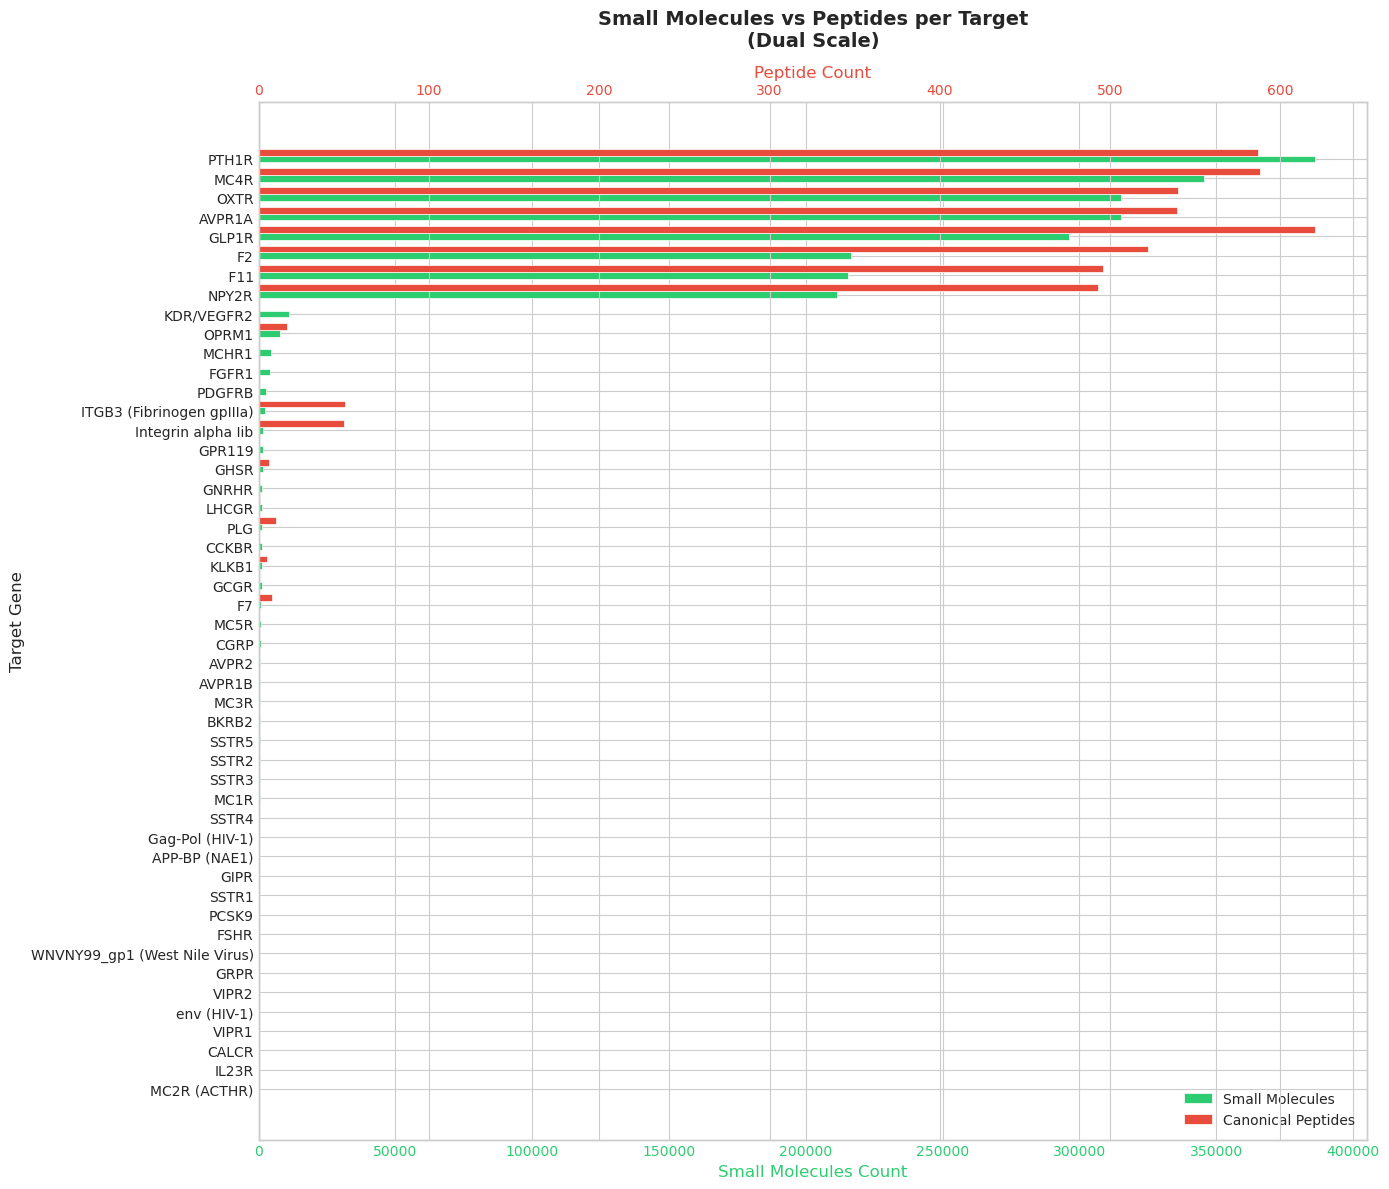

Plot saved to /fsx/amira/papyrus_target_prioritization/plot_sm_vs_peptides_per_target.png


In [25]:
# =============================================================================
# Plot 1: Peptides vs Small Molecules Content per Target (Dual Axis)
# =============================================================================

# Prepare data: count unique molecules per target and class
target_class_counts = papyrus_df.groupby(['Gene', 'predicted_mol_class']).agg({
    'SMILES': 'nunique'
}).reset_index()
target_class_counts.columns = ['Gene', 'MoleculeClass', 'Count']

# Pivot for plotting
plot_pivot = target_class_counts.pivot(index='Gene', columns='MoleculeClass', values='Count').fillna(0)

# Select only sm and can_peptide columns (if they exist)
if 'sm' in plot_pivot.columns and 'can_peptide' in plot_pivot.columns:
    plot_data = plot_pivot[['sm', 'can_peptide']].copy()
    plot_data = plot_data.sort_values('sm', ascending=True)  # Sort ascending for horizontal bars
    
    # Create figure with dual axes
    fig, ax1 = plt.subplots(figsize=(14, 12))
    
    y_pos = np.arange(len(plot_data))
    bar_height = 0.35
    
    # Left axis - Small Molecules (green bars going left from center)
    bars1 = ax1.barh(y_pos, plot_data['sm'], height=bar_height, 
                     color='#2ecc71', edgecolor='white', linewidth=0.5, label='Small Molecules')
    ax1.set_xlabel('Small Molecules Count', fontsize=12, color='#2ecc71')
    ax1.tick_params(axis='x', labelcolor='#2ecc71')
    ax1.set_ylabel('Target Gene', fontsize=12)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(plot_data.index)
    
    # Right axis - Peptides (red bars)
    ax2 = ax1.twiny()
    bars2 = ax2.barh(y_pos + bar_height, plot_data['can_peptide'], height=bar_height,
                     color='#e74c3c', edgecolor='white', linewidth=0.5, label='Canonical Peptides')
    ax2.set_xlabel('Peptide Count', fontsize=12, color='#e74c3c')
    ax2.tick_params(axis='x', labelcolor='#e74c3c')
    ax2.xaxis.set_label_position('top')
    ax2.xaxis.tick_top()
    
    # Title
    ax1.set_title('Small Molecules vs Peptides per Target\n(Dual Scale)', 
                  fontsize=14, fontweight='bold', pad=40)
    
    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
    
    plt.tight_layout()
    plt.savefig(f"{work_dir}/plot_sm_vs_peptides_per_target.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Plot saved to {work_dir}/plot_sm_vs_peptides_per_target.png")
else:
    print("Required columns not found for plotting.")


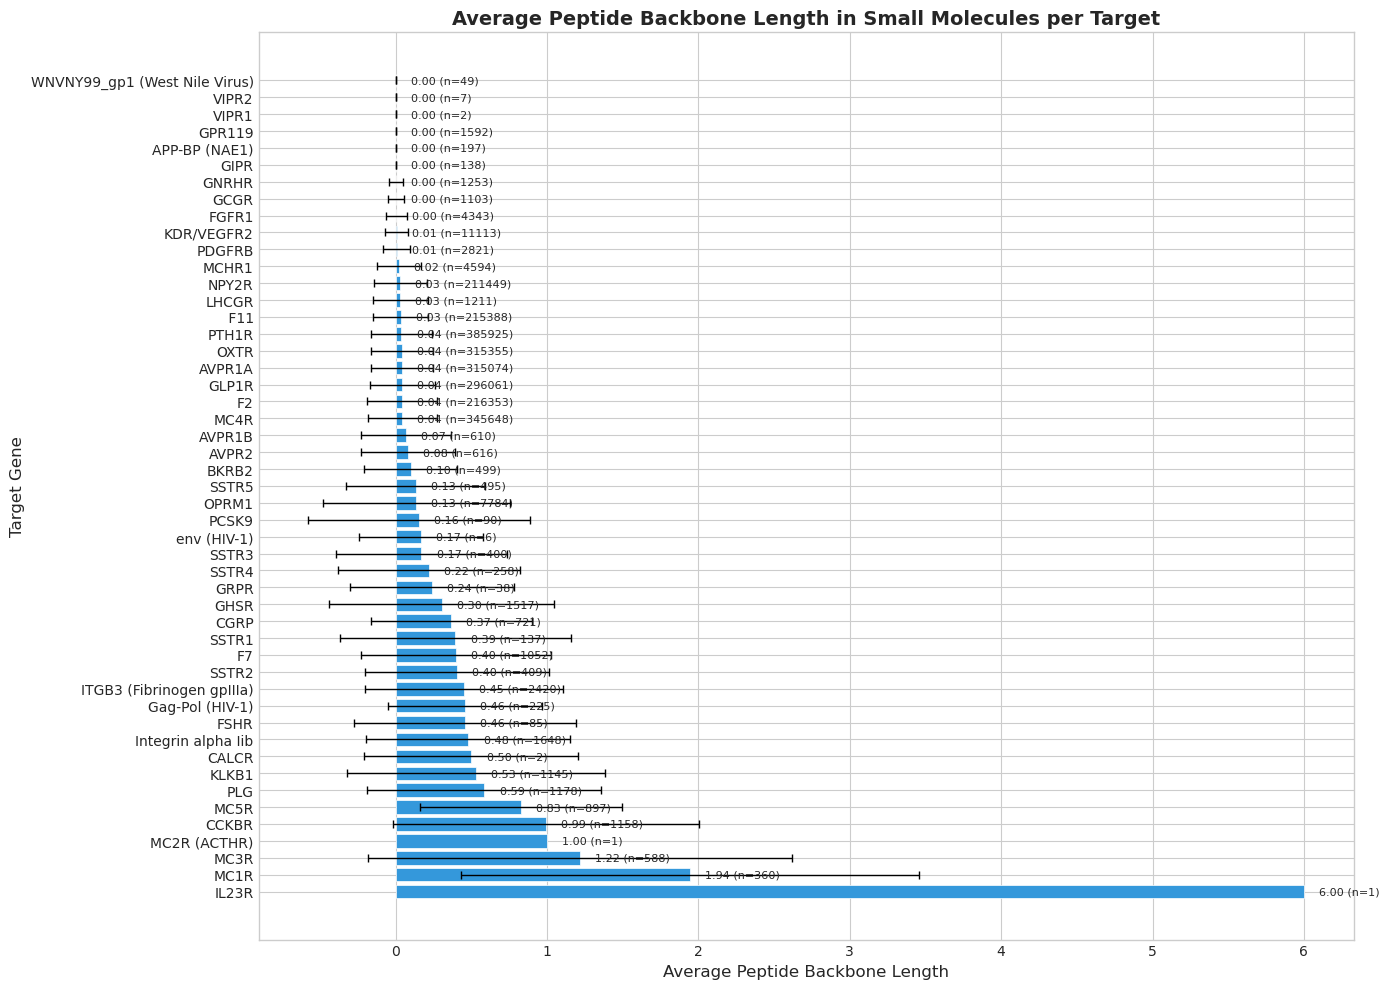

Plot saved to /fsx/amira/papyrus_target_prioritization/plot_avg_backbone_length_sm_per_target.png

Summary Statistics:


,Gene,Mean_Backbone_Length,Std_Backbone_Length,N_Molecules
21,IL23R,6.000000,NaN,1
27,MC1R,1.941667,1.512966,360
29,MC3R,1.219388,1.400109,588
28,MC2R (ACTHR),1.000000,NaN,1
7,CCKBR,0.993955,1.010300,1158
31,MC5R,0.828317,0.667786,897
38,PLG,0.585739,0.773302,1178
25,KLKB1,0.528384,0.851432,1145
6,CALCR,0.500000,0.707107,2
23,Integrin alpha Iib,0.479976,0.673616,1648


In [26]:
# =============================================================================
# Plot 2: Average Peptide Backbone Length for Small Molecules per Target
# =============================================================================

# Filter to small molecules only
sm_data = papyrus_df[papyrus_df['predicted_mol_class'] == 'sm'].copy()

# Calculate average peptide_backbone_length per target
avg_backbone_by_target = sm_data.groupby('Gene').agg({
    'peptide_backbone_length': ['mean', 'std', 'count']
}).reset_index()
avg_backbone_by_target.columns = ['Gene', 'Mean_Backbone_Length', 'Std_Backbone_Length', 'N_Molecules']

# Sort by mean backbone length
avg_backbone_by_target = avg_backbone_by_target.sort_values('Mean_Backbone_Length', ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Bar plot with error bars
bars = ax.barh(avg_backbone_by_target['Gene'], 
               avg_backbone_by_target['Mean_Backbone_Length'],
               xerr=avg_backbone_by_target['Std_Backbone_Length'],
               color='#3498db', edgecolor='white', linewidth=0.5,
               capsize=3, error_kw={'elinewidth': 1, 'capthick': 1})

ax.set_xlabel('Average Peptide Backbone Length', fontsize=12)
ax.set_ylabel('Target Gene', fontsize=12)
ax.set_title('Average Peptide Backbone Length in Small Molecules per Target', 
             fontsize=14, fontweight='bold')

# Add value labels
for i, (gene, row) in enumerate(avg_backbone_by_target.iterrows()):
    ax.text(row['Mean_Backbone_Length'] + 0.1, i, 
            f"{row['Mean_Backbone_Length']:.2f} (n={int(row['N_Molecules'])})", 
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f"{work_dir}/plot_avg_backbone_length_sm_per_target.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Plot saved to {work_dir}/plot_avg_backbone_length_sm_per_target.png")

# Display summary table
print("\nSummary Statistics:")
display(avg_backbone_by_target)


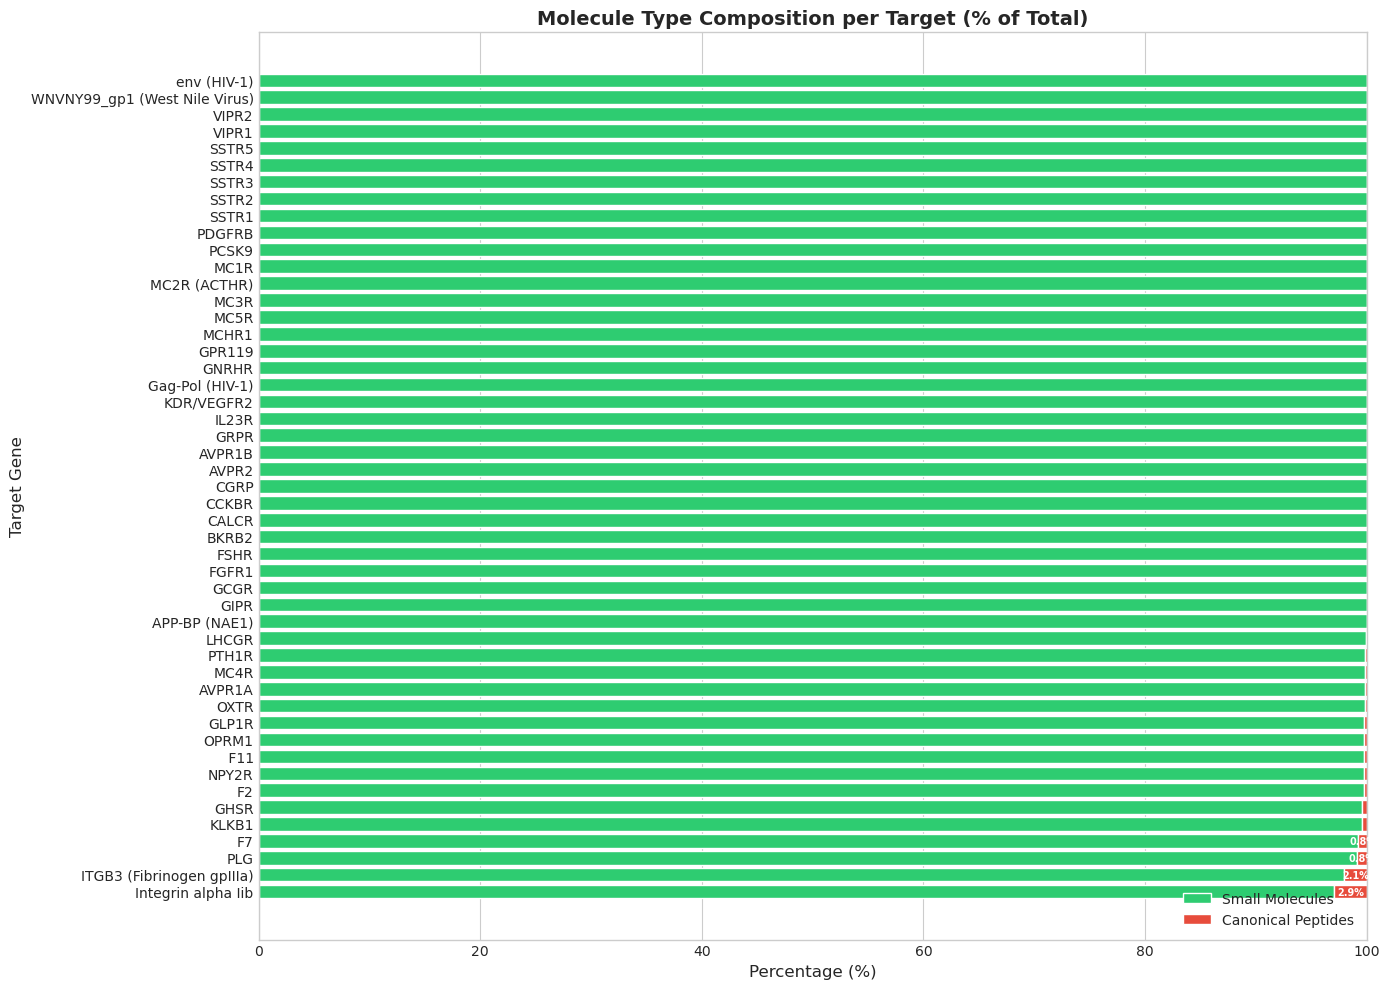

Plot saved to /fsx/amira/papyrus_target_prioritization/plot_molecule_composition_per_target.png

Targets with highest peptide content:


,SM_Count,Peptide_Count,Peptide_%
Gene,,,
Integrin alpha Iib,1648.0,50.0,2.944641
ITGB3 (Fibrinogen gpIIIa),2420.0,51.0,2.063942
PLG,1178.0,10.0,0.841751
F7,1052.0,8.0,0.754717
KLKB1,1145.0,5.0,0.434783
GHSR,1517.0,6.0,0.393959
F2,216353.0,522.0,0.240692
NPY2R,211449.0,493.0,0.232611
F11,215388.0,496.0,0.229753


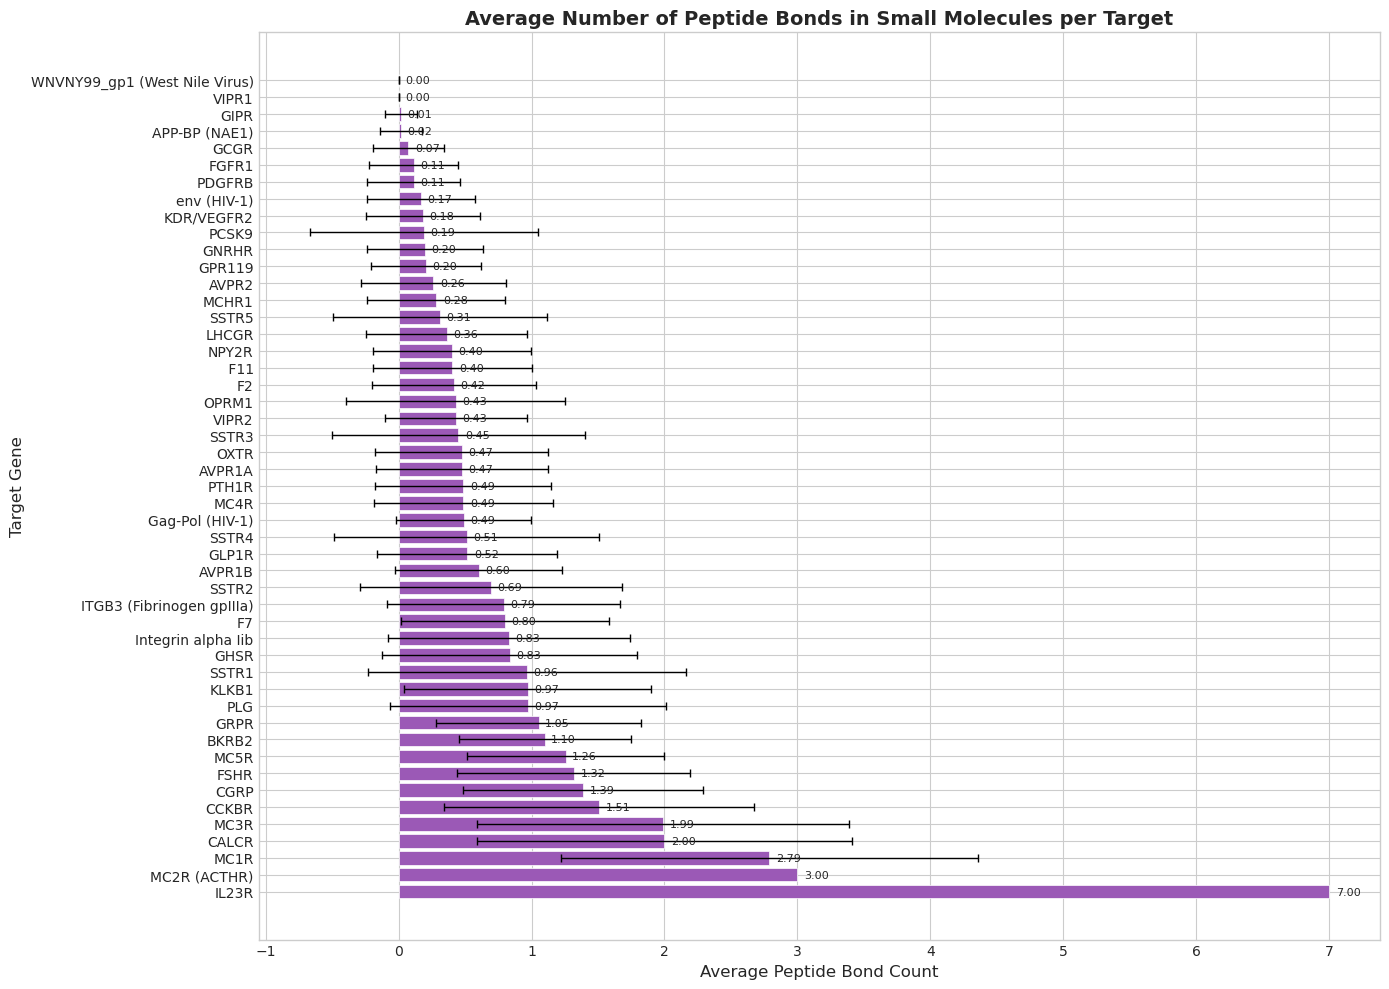

Plot saved to /fsx/amira/papyrus_target_prioritization/plot_avg_peptide_bonds_sm_per_target.png

Average Peptide Bonds in Small Molecules by Target:


,Gene,Mean_Peptide_Bonds,Std_Peptide_Bonds,N_Molecules
21,IL23R,7.000000,NaN,1
28,MC2R (ACTHR),3.000000,NaN,1
27,MC1R,2.788889,1.569163,360
6,CALCR,2.000000,1.414214,2
29,MC3R,1.989796,1.398429,588
7,CCKBR,1.506045,1.165426,1158
8,CGRP,1.385576,0.901241,721
12,FSHR,1.317647,0.875755,85
31,MC5R,1.256410,0.740284,897
5,BKRB2,1.098196,0.646567,499


In [28]:
# =============================================================================
# Plot 3: Percentage Composition - Peptides vs Small Molecules per Target
# =============================================================================

# Calculate percentages
if 'sm' in plot_pivot.columns and 'can_peptide' in plot_pivot.columns:
    pct_data = plot_pivot[['sm', 'can_peptide']].copy()
    pct_data['total'] = pct_data.sum(axis=1)
    pct_data['sm_pct'] = (pct_data['sm'] / pct_data['total']) * 100
    pct_data['peptide_pct'] = (pct_data['can_peptide'] / pct_data['total']) * 100
    
    # Sort by peptide percentage (highest first)
    pct_data = pct_data.sort_values('peptide_pct', ascending=False)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Stacked percentage bar
    ax.barh(pct_data.index, pct_data['sm_pct'], color='#2ecc71', label='Small Molecules', edgecolor='white')
    ax.barh(pct_data.index, pct_data['peptide_pct'], left=pct_data['sm_pct'], 
            color='#e74c3c', label='Canonical Peptides', edgecolor='white')
    
    ax.set_xlabel('Percentage (%)', fontsize=12)
    ax.set_ylabel('Target Gene', fontsize=12)
    ax.set_title('Molecule Type Composition per Target (% of Total)', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')
    ax.set_xlim(0, 100)
    
    # Add percentage labels
    for i, (gene, row) in enumerate(pct_data.iterrows()):
        if row['peptide_pct'] > 0.5:  # Only show if > 0.5%
            ax.text(row['sm_pct'] + row['peptide_pct']/2, i, 
                    f"{row['peptide_pct']:.1f}%", 
                    va='center', ha='center', fontsize=7, color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f"{work_dir}/plot_molecule_composition_per_target.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Plot saved to {work_dir}/plot_molecule_composition_per_target.png")
    
    # Show targets with highest peptide content
    print("\nTargets with highest peptide content:")
    top_peptide_targets = pct_data[['sm', 'can_peptide', 'peptide_pct']].head(10)
    top_peptide_targets.columns = ['SM_Count', 'Peptide_Count', 'Peptide_%']
    display(top_peptide_targets)
else:
    print("Required columns not found.")

# =============================================================================
# Plot 3b: Average Peptide Bond Count for Small Molecules per Target
# =============================================================================

# Filter to small molecules only
sm_data_bonds = papyrus_df[papyrus_df['predicted_mol_class'] == 'sm'].copy()

# Calculate average peptide_bond_count per target
avg_bonds_by_target = sm_data_bonds.groupby('Gene').agg({
    'peptide_bond_count': ['mean', 'std', 'count']
}).reset_index()
avg_bonds_by_target.columns = ['Gene', 'Mean_Peptide_Bonds', 'Std_Peptide_Bonds', 'N_Molecules']

# Sort by mean peptide bond count
avg_bonds_by_target = avg_bonds_by_target.sort_values('Mean_Peptide_Bonds', ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Bar plot with error bars
bars = ax.barh(avg_bonds_by_target['Gene'], 
               avg_bonds_by_target['Mean_Peptide_Bonds'],
               xerr=avg_bonds_by_target['Std_Peptide_Bonds'],
               color='#9b59b6', edgecolor='white', linewidth=0.5,
               capsize=3, error_kw={'elinewidth': 1, 'capthick': 1})

ax.set_xlabel('Average Peptide Bond Count', fontsize=12)
ax.set_ylabel('Target Gene', fontsize=12)
ax.set_title('Average Number of Peptide Bonds in Small Molecules per Target', 
             fontsize=14, fontweight='bold')

# Add value labels
for i, (idx, row) in enumerate(avg_bonds_by_target.iterrows()):
    ax.text(row['Mean_Peptide_Bonds'] + 0.05, i, 
            f"{row['Mean_Peptide_Bonds']:.2f}", 
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f"{work_dir}/plot_avg_peptide_bonds_sm_per_target.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Plot saved to {work_dir}/plot_avg_peptide_bonds_sm_per_target.png")

# Display summary table
print("\nAverage Peptide Bonds in Small Molecules by Target:")
display(avg_bonds_by_target)


In [29]:
# =============================================================================
# REPEAT ANALYSIS WITH ACTIVITY-FILTERED DATA
# =============================================================================
# This section uses only molecules with pChEMBL activity values
# =============================================================================

print("=" * 80)
print("ANALYSIS OF MOLECULES WITH ACTIVITY VALUES")
print("=" * 80)

# Load activity-filtered data
activity_file = f"{work_dir}/papyrus_filtered_with_activity.tsv.xz"

# Check if file exists in work_dir, otherwise use local
if not os.path.exists(activity_file):
    activity_file = "papyrus_filtered_with_activity.tsv.xz"
    
print(f"Loading data from: {activity_file}")

activity_df = pd.read_csv(activity_file, sep='\t', compression='xz')
print(f"Loaded {len(activity_df):,} records with activity values")
print(f"Columns: {activity_df.columns.tolist()[:10]}...")
print(f"\nUnique SMILES: {activity_df['SMILES'].nunique():,}")
print(f"pChEMBL range: {activity_df['pchembl_value_Mean'].min():.2f} - {activity_df['pchembl_value_Mean'].max():.2f}")
activity_df.head()


ANALYSIS OF MOLECULES WITH ACTIVITY VALUES
Loading data from: /fsx/amira/papyrus_target_prioritization/papyrus_filtered_with_activity.tsv.xz
Loaded 104,867 records with activity values
Columns: ['Activity_ID', 'Quality', 'source', 'CID', 'SMILES', 'connectivity', 'InChIKey', 'InChI', 'InChI_AuxInfo', 'target_id']...

Unique SMILES: 92,706
pChEMBL range: 3.02 - 13.00


,Activity_ID,Quality,source,CID,SMILES,connectivity,InChIKey,InChI,InChI_AuxInfo,target_id,...,Activity_class,relation,pchembl_value,pchembl_value_Mean,pchembl_value_StdDev,pchembl_value_SEM,pchembl_value_N,pchembl_value_Median,pchembl_value_MAD,Gene
0,AAABHMIRDIOYOK_on_P43220_WT,High,ExCAPE-DB,3147229,Cn1cc([N+](=O)[O-])c(C(=O)Nc2ccc3[nH]c(-c4cccc...,AAABHMIRDIOYOK,AAABHMIRDIOYOK-UHFFFAOYSA-N,InChI=1S/C18H14N6O3/c1-23-10-15(24(26)27)16(22...,"""AuxInfo=1/1/N:1,21,20,22,19,23,13,14,26,3,18,...",P43220_WT,...,NaN,=,4.950,4.950,0.000,0.000,1.0,4.95,0.0,GLP1R
1,AAAHTCZONLHYSA_on_P09619_WT,Medium,ChEMBL31,ChEMBL31.compound.100279,Nc1ccccc1NC(=O)c1ccc(C(=O)Nc2cc(Nc3ncc(-c4cccn...,AAAHTCZONLHYSA,AAAHTCZONLHYSA-UHFFFAOYSA-N,InChI=1S/C26H20N6O2S2/c27-19-8-1-2-9-20(19)32-...,"""AuxInfo=1/1/N:4,5,34,28,27,35,33,3,6,13,12,29...",P09619_WT,...,NaN,=,4.550,4.550,0.000,0.000,1.0,4.55,0.0,PDGFRB
2,AAAHTCZONLHYSA_on_P35968_WT,Medium,ChEMBL31,ChEMBL31.compound.100279,Nc1ccccc1NC(=O)c1ccc(C(=O)Nc2cc(Nc3ncc(-c4cccn...,AAAHTCZONLHYSA,AAAHTCZONLHYSA-UHFFFAOYSA-N,InChI=1S/C26H20N6O2S2/c27-19-8-1-2-9-20(19)32-...,"""AuxInfo=1/1/N:4,5,34,28,27,35,33,3,6,13,12,29...",P35968_WT,...,NaN,=,4.920,4.920,0.000,0.000,1.0,4.92,0.0,KDR/VEGFR2
3,AAAOTGDHZDZLFN_on_P30968_WT,High,ExCAPE-DB;ChEMBL31;ChEMBL31,53388960;ChEMBL31.compound.162624;ChEMBL31.com...,CONC(=O)Nc1ccc(-c2c(CN(C)CCc3ccccn3)c3c(s2)n(C...,AAAOTGDHZDZLFN,AAAOTGDHZDZLFN-UHFFFAOYSA-N,InChI=1S/C36H32F2N6O4S/c1-42(20-18-24-9-6-7-19...,"""AuxInfo=1/1/N:15,1,43,42,44,20,21,33,19,41,45...",P30968_WT,...,NaN,=,10.155; 10.150; 10.150,10.152,0.002,0.002,3.0,10.15,0.0,GNRHR
4,AAAXBDFZRXKRPL_on_P35968_WT,Medium,ChEMBL31,ChEMBL31.compound.122973,C#Cc1cccc(Nc2nccc3c2ccc(C)c3Nc2ncccc2-c2ncnc(N...,AAAXBDFZRXKRPL,AAAXBDFZRXKRPL-UHFFFAOYSA-N,InChI=1S/C28H23N7/c1-4-19-7-5-8-20(15-19)34-27...,"""AuxInfo=1/1/N:1,18,33,2,5,24,4,6,25,16,15,12,...",P35968_WT,...,NaN,=,6.380,6.380,0.000,0.000,1.0,6.38,0.0,KDR/VEGFR2


In [34]:
# =============================================================================
# Extract Features for Activity Data
# =============================================================================

# Get unique SMILES from activity data
unique_smiles_activity = activity_df['SMILES'].dropna().unique()
print(f"Extracting features for {len(unique_smiles_activity):,} unique SMILES with activity data...")

# Extract features
features_activity_df = featurize_smiles_batch(unique_smiles_activity)

print(f"\nFeatures extracted: {features_activity_df.shape[1]} columns")
features_activity_df.head()


Extracting features for 92,706 unique SMILES with activity data...


Extracting features:   0%|          | 0/92706 [00:00<?, ?it/s]


Features extracted: 49 columns


,molecular_weight,heavy_atom_count,ring_count,largest_ring_size,percent_heavy_in_rings,rotatable_bonds,peptide_bond_count,peptide_backbone_length,nucleotide_count,glycosidic_bond_count,...,pattern_AA_THREONINE,pattern_AA_GLUTAMINE,pattern_AA_ASPARAGINE,pattern_GALACTOSE,pattern_GLUCOSE,pattern_MANNOSE,pattern_NUCLEOBASE_CYTOSINE,pattern_PHOSPHATE_BACKBONE,pattern_NUCLEOBASE_URACIL,pattern_NUCLEOBASE_THYMINE
0,362.349,27,4,6,74.074074,4,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,512.620,36,5,6,77.777778,7,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,682.753,49,6,6,67.346939,11,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,457.541,35,5,6,80.000000,6,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,481.145,25,1,6,24.000000,8,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# =============================================================================
# Classify Activity Data Molecules
# =============================================================================

if clf is not None and label_encoder is not None:
    print("Classifying molecules with activity data...")
    
    # Reindex to match model's expected features (fill missing with 0)
    X_activity = features_activity_df.reindex(columns=MODEL_FEATURE_COLUMNS, fill_value=0).values
    X_activity = np.nan_to_num(X_activity, nan=0.0).astype(np.float32)
    
    print(f"Feature matrix shape: {X_activity.shape}")
    
    # Predict classes
    predictions_activity = clf.predict(X_activity)
    pred_labels_activity = label_encoder.inverse_transform(predictions_activity)
    
    # Create mapping from SMILES to prediction
    smiles_to_pred_activity = dict(zip(unique_smiles_activity, pred_labels_activity))
    
    # Map predictions back to activity dataframe
    activity_df['predicted_mol_class'] = activity_df['SMILES'].map(smiles_to_pred_activity)
    
    print(f"\nClassification complete!")
    print(f"\nClass distribution (molecules with activity):")
    print(activity_df['predicted_mol_class'].value_counts())
else:
    print("Model not available.")


Classifying molecules with activity data...
Feature matrix shape: (92706, 52)

Classification complete!

Class distribution (molecules with activity):
predicted_mol_class
sm             103705
unwanted          963
can_peptide       199
Name: count, dtype: int64


In [36]:
# =============================================================================
# Merge Features with Activity Data
# =============================================================================

# Create features lookup
features_activity_df['SMILES'] = unique_smiles_activity
smiles_features_activity = features_activity_df.set_index('SMILES')

# Add key features to activity_df
activity_df['peptide_backbone_length'] = activity_df['SMILES'].map(
    smiles_features_activity['peptide_backbone_length'].to_dict()
)
activity_df['molecular_weight'] = activity_df['SMILES'].map(
    smiles_features_activity['molecular_weight'].to_dict()
)
activity_df['peptide_bond_count'] = activity_df['SMILES'].map(
    smiles_features_activity['peptide_bond_count'].to_dict()
)

# Also add Gene column if not present (from accession mapping)
if 'Gene' not in activity_df.columns:
    # Create gene mapping from original papyrus_df if available
    if 'papyrus_df' in dir() and 'Gene' in papyrus_df.columns:
        accession_to_gene = papyrus_df[['accession', 'Gene']].drop_duplicates().set_index('accession')['Gene'].to_dict()
        activity_df['Gene'] = activity_df['accession'].map(accession_to_gene)

print("Features merged with activity data.")
print(f"\nActivity data summary:")
print(f"  Total records: {len(activity_df):,}")
print(f"  Unique SMILES: {activity_df['SMILES'].nunique():,}")
print(f"  Unique targets: {activity_df['Gene'].nunique()}")


Features merged with activity data.

Activity data summary:
  Total records: 104,867
  Unique SMILES: 92,706
  Unique targets: 49


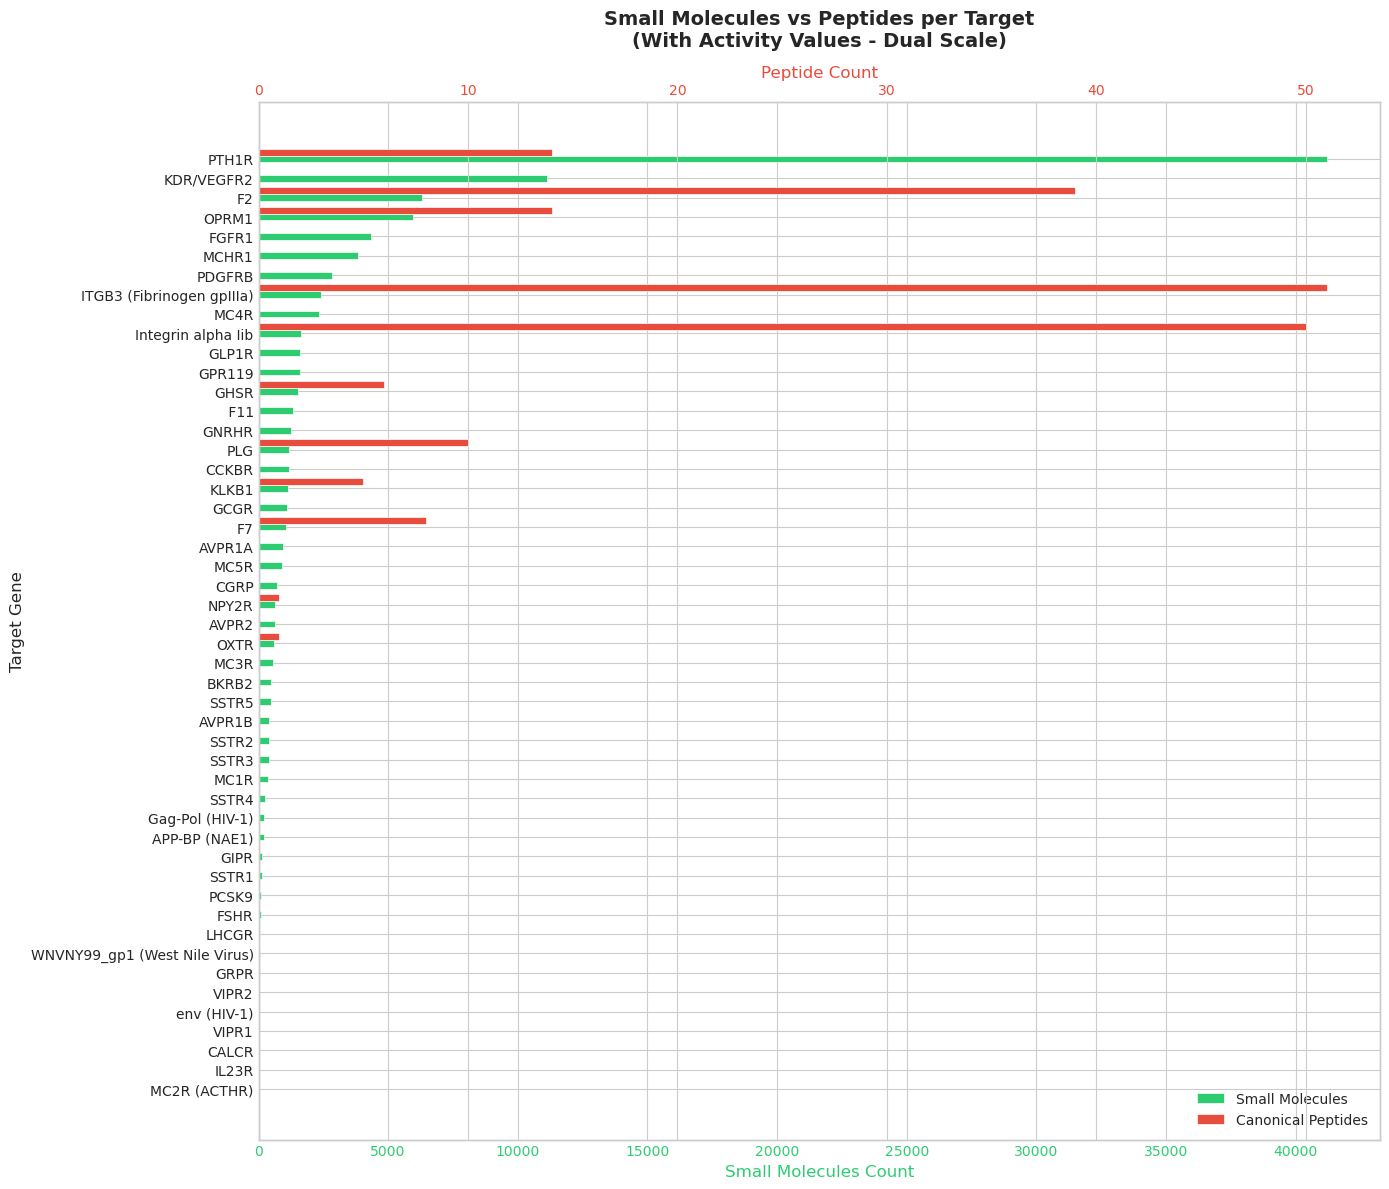

Plot saved to /fsx/amira/papyrus_target_prioritization/plot_sm_vs_peptides_activity_data.png


In [37]:
# =============================================================================
# Plot 4: Peptides vs Small Molecules (Activity Data - Dual Axis)
# =============================================================================

# Prepare data for activity molecules
activity_class_counts = activity_df.groupby(['Gene', 'predicted_mol_class']).agg({
    'SMILES': 'nunique'
}).reset_index()
activity_class_counts.columns = ['Gene', 'MoleculeClass', 'Count']

# Pivot for plotting
activity_pivot = activity_class_counts.pivot(index='Gene', columns='MoleculeClass', values='Count').fillna(0)

if 'sm' in activity_pivot.columns and 'can_peptide' in activity_pivot.columns:
    activity_plot_data = activity_pivot[['sm', 'can_peptide']].copy()
    activity_plot_data = activity_plot_data.sort_values('sm', ascending=True)
    
    # Create figure with dual axes
    fig, ax1 = plt.subplots(figsize=(14, 12))
    
    y_pos = np.arange(len(activity_plot_data))
    bar_height = 0.35
    
    # Left axis - Small Molecules
    bars1 = ax1.barh(y_pos, activity_plot_data['sm'], height=bar_height, 
                     color='#2ecc71', edgecolor='white', linewidth=0.5, label='Small Molecules')
    ax1.set_xlabel('Small Molecules Count', fontsize=12, color='#2ecc71')
    ax1.tick_params(axis='x', labelcolor='#2ecc71')
    ax1.set_ylabel('Target Gene', fontsize=12)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(activity_plot_data.index)
    
    # Right axis - Peptides
    ax2 = ax1.twiny()
    bars2 = ax2.barh(y_pos + bar_height, activity_plot_data['can_peptide'], height=bar_height,
                     color='#e74c3c', edgecolor='white', linewidth=0.5, label='Canonical Peptides')
    ax2.set_xlabel('Peptide Count', fontsize=12, color='#e74c3c')
    ax2.tick_params(axis='x', labelcolor='#e74c3c')
    ax2.xaxis.set_label_position('top')
    ax2.xaxis.tick_top()
    
    ax1.set_title('Small Molecules vs Peptides per Target\n(With Activity Values - Dual Scale)', 
                  fontsize=14, fontweight='bold', pad=40)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
    
    plt.tight_layout()
    plt.savefig(f"{work_dir}/plot_sm_vs_peptides_activity_data.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Plot saved to {work_dir}/plot_sm_vs_peptides_activity_data.png")
else:
    print("Required columns not found.")


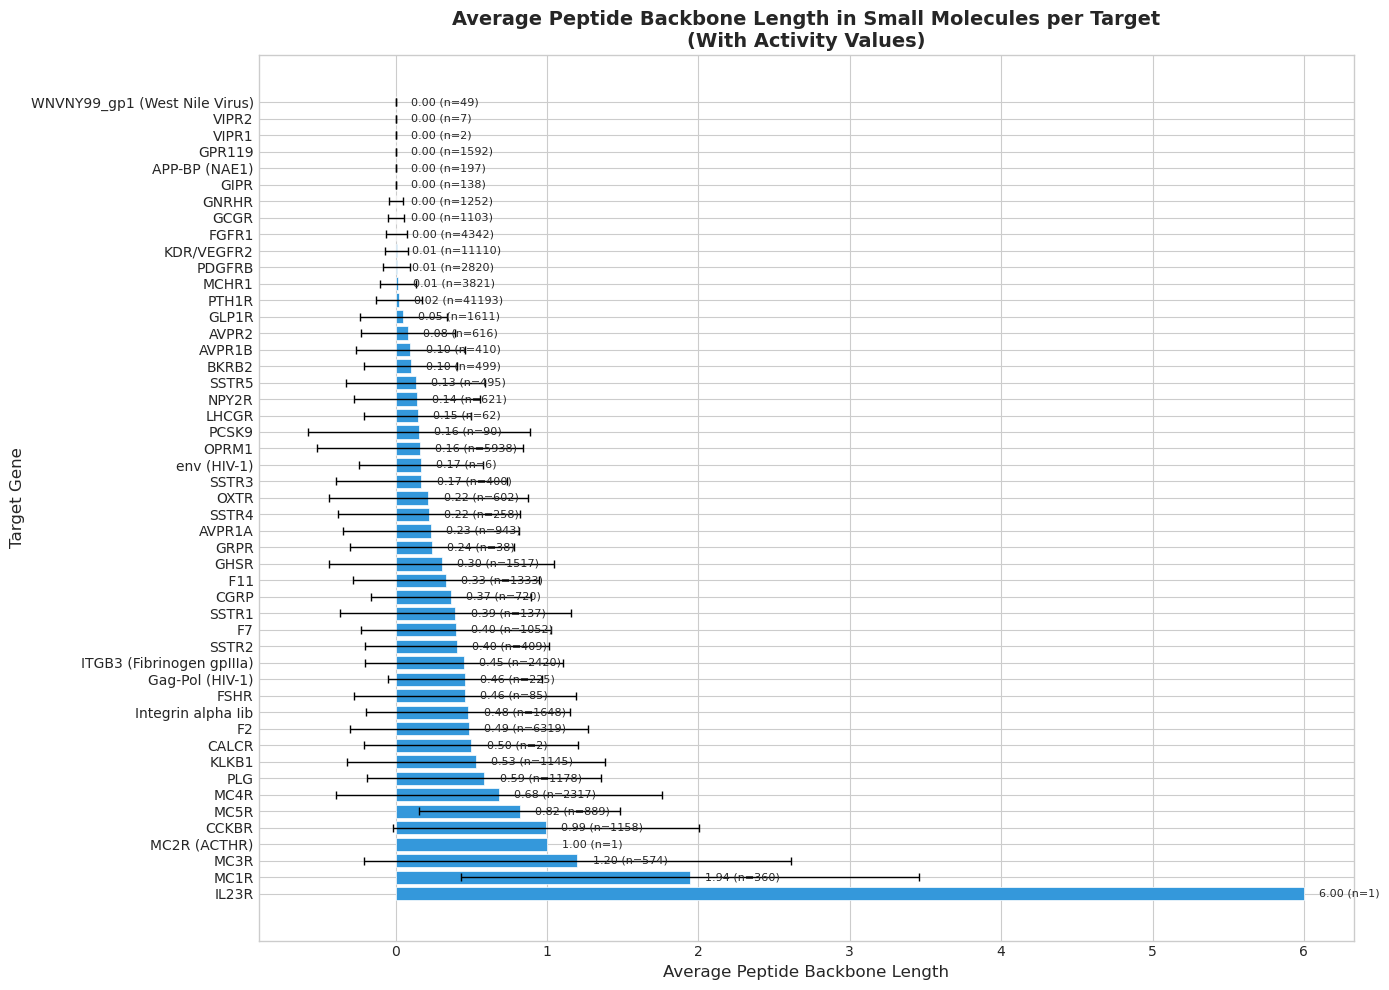

Plot saved to /fsx/amira/papyrus_target_prioritization/plot_avg_backbone_length_sm_activity_data.png

Summary Statistics (Activity Data):


,Gene,Mean_Backbone_Length,Std_Backbone_Length,N_Molecules
21,IL23R,6.000000,NaN,1
27,MC1R,1.941667,1.512966,360
29,MC3R,1.200348,1.411719,574
28,MC2R (ACTHR),1.000000,NaN,1
7,CCKBR,0.993955,1.010300,1158
31,MC5R,0.817773,0.661420,889
30,MC4R,0.681485,1.077910,2317
38,PLG,0.585739,0.773302,1178
25,KLKB1,0.528384,0.851432,1145
6,CALCR,0.500000,0.707107,2


In [38]:
# =============================================================================
# Plot 5: Average Peptide Backbone Length for SM (Activity Data)
# =============================================================================

# Filter to small molecules only
sm_activity_data = activity_df[activity_df['predicted_mol_class'] == 'sm'].copy()

# Calculate average peptide_backbone_length per target
avg_backbone_activity = sm_activity_data.groupby('Gene').agg({
    'peptide_backbone_length': ['mean', 'std', 'count']
}).reset_index()
avg_backbone_activity.columns = ['Gene', 'Mean_Backbone_Length', 'Std_Backbone_Length', 'N_Molecules']

# Sort by mean backbone length
avg_backbone_activity = avg_backbone_activity.sort_values('Mean_Backbone_Length', ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Bar plot with error bars
bars = ax.barh(avg_backbone_activity['Gene'], 
               avg_backbone_activity['Mean_Backbone_Length'],
               xerr=avg_backbone_activity['Std_Backbone_Length'],
               color='#3498db', edgecolor='white', linewidth=0.5,
               capsize=3, error_kw={'elinewidth': 1, 'capthick': 1})

ax.set_xlabel('Average Peptide Backbone Length', fontsize=12)
ax.set_ylabel('Target Gene', fontsize=12)
ax.set_title('Average Peptide Backbone Length in Small Molecules per Target\n(With Activity Values)', 
             fontsize=14, fontweight='bold')

# Add value labels
for i, (idx, row) in enumerate(avg_backbone_activity.iterrows()):
    ax.text(row['Mean_Backbone_Length'] + 0.1, i, 
            f"{row['Mean_Backbone_Length']:.2f} (n={int(row['N_Molecules'])})", 
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f"{work_dir}/plot_avg_backbone_length_sm_activity_data.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Plot saved to {work_dir}/plot_avg_backbone_length_sm_activity_data.png")

# Display summary
print("\nSummary Statistics (Activity Data):")
display(avg_backbone_activity)


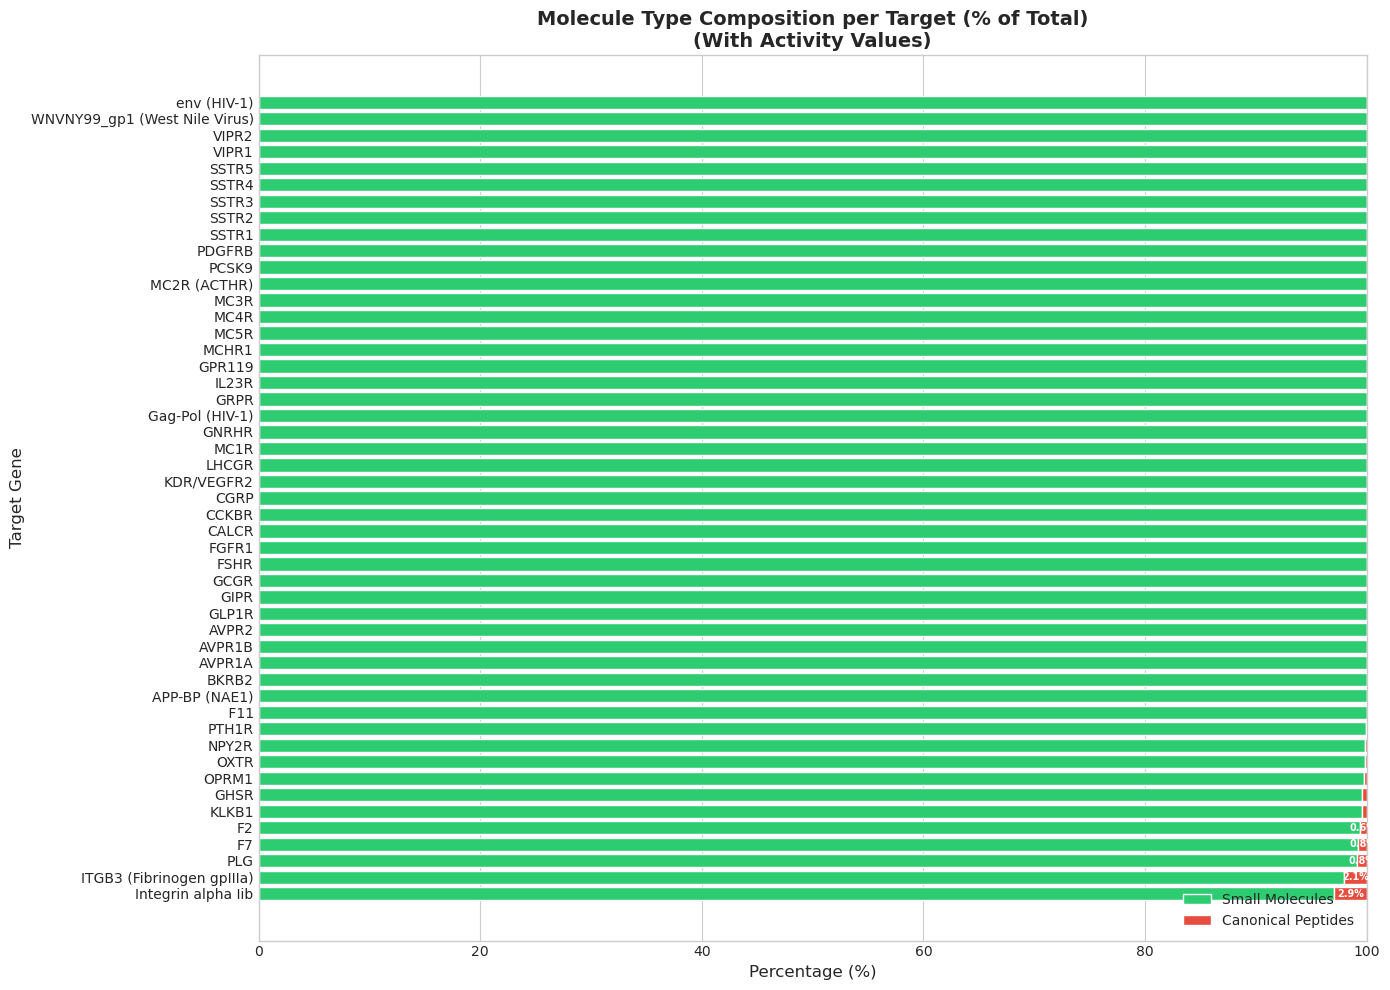

Plot saved to /fsx/amira/papyrus_target_prioritization/plot_molecule_composition_activity_data.png

Targets with highest peptide content (Activity Data):


,SM_Count,Peptide_Count,Peptide_%
Gene,,,
Integrin alpha Iib,1648.0,50.0,2.944641
ITGB3 (Fibrinogen gpIIIa),2420.0,51.0,2.063942
PLG,1178.0,10.0,0.841751
F7,1052.0,8.0,0.754717
F2,6319.0,39.0,0.613400
KLKB1,1145.0,5.0,0.434783
GHSR,1517.0,6.0,0.393959
OPRM1,5938.0,14.0,0.235215
OXTR,602.0,1.0,0.165837


In [39]:
# =============================================================================
# Plot 6: Percentage Composition (Activity Data)
# =============================================================================

if 'sm' in activity_pivot.columns and 'can_peptide' in activity_pivot.columns:
    pct_activity_data = activity_pivot[['sm', 'can_peptide']].copy()
    pct_activity_data['total'] = pct_activity_data.sum(axis=1)
    pct_activity_data['sm_pct'] = (pct_activity_data['sm'] / pct_activity_data['total']) * 100
    pct_activity_data['peptide_pct'] = (pct_activity_data['can_peptide'] / pct_activity_data['total']) * 100
    
    # Sort by peptide percentage
    pct_activity_data = pct_activity_data.sort_values('peptide_pct', ascending=False)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Stacked percentage bar
    ax.barh(pct_activity_data.index, pct_activity_data['sm_pct'], 
            color='#2ecc71', label='Small Molecules', edgecolor='white')
    ax.barh(pct_activity_data.index, pct_activity_data['peptide_pct'], 
            left=pct_activity_data['sm_pct'], color='#e74c3c', label='Canonical Peptides', edgecolor='white')
    
    ax.set_xlabel('Percentage (%)', fontsize=12)
    ax.set_ylabel('Target Gene', fontsize=12)
    ax.set_title('Molecule Type Composition per Target (% of Total)\n(With Activity Values)', 
                 fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')
    ax.set_xlim(0, 100)
    
    # Add percentage labels
    for i, (gene, row) in enumerate(pct_activity_data.iterrows()):
        if row['peptide_pct'] > 0.5:
            ax.text(row['sm_pct'] + row['peptide_pct']/2, i, 
                    f"{row['peptide_pct']:.1f}%", 
                    va='center', ha='center', fontsize=7, color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f"{work_dir}/plot_molecule_composition_activity_data.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Plot saved to {work_dir}/plot_molecule_composition_activity_data.png")
    
    # Show targets with highest peptide content
    print("\nTargets with highest peptide content (Activity Data):")
    top_peptide_activity = pct_activity_data[['sm', 'can_peptide', 'peptide_pct']].head(10)
    top_peptide_activity.columns = ['SM_Count', 'Peptide_Count', 'Peptide_%']
    display(top_peptide_activity)
else:
    print("Required columns not found.")


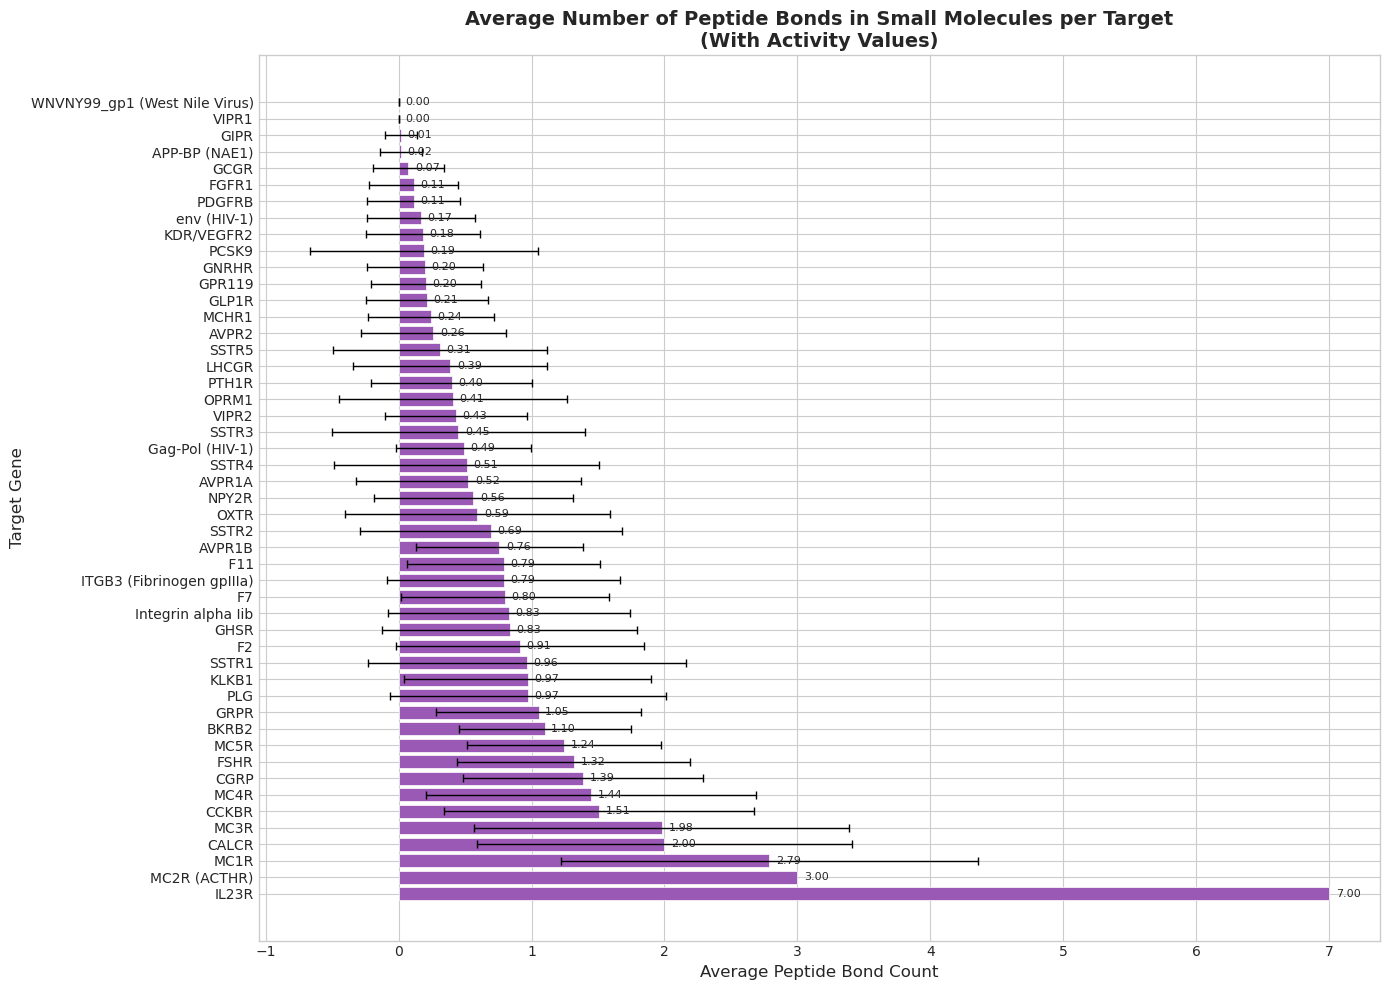

Plot saved to /fsx/amira/papyrus_target_prioritization/plot_avg_peptide_bonds_sm_activity_data.png

Average Peptide Bonds in Small Molecules by Target (Activity Data):


,Gene,Mean_Peptide_Bonds,Std_Peptide_Bonds,N_Molecules
21,IL23R,7.000000,NaN,1
28,MC2R (ACTHR),3.000000,NaN,1
27,MC1R,2.788889,1.569163,360
6,CALCR,2.000000,1.414214,2
29,MC3R,1.979094,1.411588,574
7,CCKBR,1.506045,1.165426,1158
30,MC4R,1.444972,1.240549,2317
8,CGRP,1.386111,0.901753,720
12,FSHR,1.317647,0.875755,85
31,MC5R,1.244094,0.730629,889


In [40]:
# =============================================================================
# Plot 6b: Average Peptide Bond Count for SM (Activity Data)
# =============================================================================

# Filter to small molecules only
sm_activity_bonds = activity_df[activity_df['predicted_mol_class'] == 'sm'].copy()

# Calculate average peptide_bond_count per target
avg_bonds_activity = sm_activity_bonds.groupby('Gene').agg({
    'peptide_bond_count': ['mean', 'std', 'count']
}).reset_index()
avg_bonds_activity.columns = ['Gene', 'Mean_Peptide_Bonds', 'Std_Peptide_Bonds', 'N_Molecules']

# Sort by mean peptide bond count
avg_bonds_activity = avg_bonds_activity.sort_values('Mean_Peptide_Bonds', ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Bar plot with error bars
bars = ax.barh(avg_bonds_activity['Gene'], 
               avg_bonds_activity['Mean_Peptide_Bonds'],
               xerr=avg_bonds_activity['Std_Peptide_Bonds'],
               color='#9b59b6', edgecolor='white', linewidth=0.5,
               capsize=3, error_kw={'elinewidth': 1, 'capthick': 1})

ax.set_xlabel('Average Peptide Bond Count', fontsize=12)
ax.set_ylabel('Target Gene', fontsize=12)
ax.set_title('Average Number of Peptide Bonds in Small Molecules per Target\n(With Activity Values)', 
             fontsize=14, fontweight='bold')

# Add value labels
for i, (idx, row) in enumerate(avg_bonds_activity.iterrows()):
    ax.text(row['Mean_Peptide_Bonds'] + 0.05, i, 
            f"{row['Mean_Peptide_Bonds']:.2f}", 
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f"{work_dir}/plot_avg_peptide_bonds_sm_activity_data.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Plot saved to {work_dir}/plot_avg_peptide_bonds_sm_activity_data.png")

# Display summary table
print("\nAverage Peptide Bonds in Small Molecules by Target (Activity Data):")
display(avg_bonds_activity)


In [41]:
# =============================================================================
# Save Classified Activity Data
# =============================================================================

if 'predicted_mol_class' in activity_df.columns:
    print(f"Saving classified activity data to {work_dir}...")
    
    # Save full classified data
    output_activity = f"{work_dir}/papyrus_activity_classified.tsv.xz"
    activity_df.to_csv(output_activity, sep='\t', index=False, compression='xz')
    print(f"  Saved {len(activity_df):,} records to {output_activity}")
    
    # Save summary
    activity_summary = activity_df.groupby(['Gene', 'predicted_mol_class']).agg({
        'SMILES': 'nunique',
        'pchembl_value_Mean': ['mean', 'std']
    }).reset_index()
    activity_summary.columns = ['Gene', 'MoleculeClass', 'N_Molecules', 'Mean_pChEMBL', 'Std_pChEMBL']
    output_activity_summary = f"{work_dir}/papyrus_activity_classified_summary.tsv"
    activity_summary.to_csv(output_activity_summary, sep='\t', index=False)
    print(f"  Saved summary to {output_activity_summary}")
    
    print("\nDone!")
    
    # Show comparison between full and activity datasets
    print("\n" + "=" * 80)
    print("COMPARISON: Full Dataset vs Activity-Filtered Dataset")
    print("=" * 80)
    print(f"\nFull dataset:")
    print(papyrus_df['predicted_mol_class'].value_counts())
    print(f"\nActivity-filtered dataset:")
    print(activity_df['predicted_mol_class'].value_counts())
else:
    print("No classification results to save.")


Saving classified activity data to /fsx/amira/papyrus_target_prioritization...
  Saved 104,867 records to /fsx/amira/papyrus_target_prioritization/papyrus_activity_classified.tsv.xz
  Saved summary to /fsx/amira/papyrus_target_prioritization/papyrus_activity_classified_summary.tsv

Done!

COMPARISON: Full Dataset vs Activity-Filtered Dataset

Full dataset:
predicted_mol_class
sm             2354016
can_peptide       4533
unwanted          1668
Name: count, dtype: int64

Activity-filtered dataset:
predicted_mol_class
sm             103705
unwanted          963
can_peptide       199
Name: count, dtype: int64


In [42]:
# =============================================================================
# Generate Summary Report
# =============================================================================

from IPython.display import display, Markdown, Image

report = f"""
# Papyrus Molecular Classification Report

## Dataset Summary

| Dataset | Records | Unique SMILES | Targets |
|---------|---------|---------------|---------|
| Full Papyrus | {len(papyrus_df):,} | {papyrus_df['SMILES'].nunique():,} | {papyrus_df['Gene'].nunique()} |
| Activity-Filtered | {len(activity_df):,} | {activity_df['SMILES'].nunique():,} | {activity_df['Gene'].nunique()} |

## Classification Results

### Full Dataset
"""

# Add classification counts
full_counts = papyrus_df['predicted_mol_class'].value_counts()
report += "\n| Class | Count | Percentage |\n|-------|-------|------------|\n"
for cls, count in full_counts.items():
    pct = count / len(papyrus_df) * 100
    report += f"| {cls} | {count:,} | {pct:.2f}% |\n"

report += "\n### Activity-Filtered Dataset\n"
activity_counts = activity_df['predicted_mol_class'].value_counts()
report += "\n| Class | Count | Percentage |\n|-------|-------|------------|\n"
for cls, count in activity_counts.items():
    pct = count / len(activity_df) * 100
    report += f"| {cls} | {count:,} | {pct:.2f}% |\n"

report += f"""
## Key Findings

1. **Small molecules dominate** the dataset ({full_counts.get('sm', 0)/len(papyrus_df)*100:.1f}% of all records)
2. **Canonical peptides** represent only {full_counts.get('can_peptide', 0)/len(papyrus_df)*100:.2f}% of the dataset
3. **Activity coverage**: {len(activity_df)/len(papyrus_df)*100:.1f}% of records have quantitative pChEMBL values

## Output Files

All results saved to: `{work_dir}/`

- `REPORT_Papyrus_Molecular_Classification.md` - Full report
- `papyrus_classified.tsv.xz` - Full classified dataset
- `papyrus_activity_classified.tsv.xz` - Activity-filtered classified data
- `plot_*.png` - Visualization figures
"""

display(Markdown(report))
print(f"\nFull report saved to: {work_dir}/REPORT_Papyrus_Molecular_Classification.md")



# Papyrus Molecular Classification Report

## Dataset Summary

| Dataset | Records | Unique SMILES | Targets |
|---------|---------|---------------|---------|
| Full Papyrus | 2,360,217 | 449,020 | 49 |
| Activity-Filtered | 104,867 | 92,706 | 49 |

## Classification Results

### Full Dataset

| Class | Count | Percentage |
|-------|-------|------------|
| sm | 2,354,016 | 99.74% |
| can_peptide | 4,533 | 0.19% |
| unwanted | 1,668 | 0.07% |

### Activity-Filtered Dataset

| Class | Count | Percentage |
|-------|-------|------------|
| sm | 103,705 | 98.89% |
| unwanted | 963 | 0.92% |
| can_peptide | 199 | 0.19% |

## Key Findings

1. **Small molecules dominate** the dataset (99.7% of all records)
2. **Canonical peptides** represent only 0.19% of the dataset
3. **Activity coverage**: 4.4% of records have quantitative pChEMBL values

## Output Files

All results saved to: `/fsx/amira/papyrus_target_prioritization/`

- `REPORT_Papyrus_Molecular_Classification.md` - Full report
- `papyrus_classified.tsv.xz` - Full classified dataset
- `papyrus_activity_classified.tsv.xz` - Activity-filtered classified data
- `plot_*.png` - Visualization figures



Full report saved to: /fsx/amira/papyrus_target_prioritization/REPORT_Papyrus_Molecular_Classification.md


GENERATED FIGURES SUMMARY

Fig 1: Small Molecules vs Peptides per Target (Full Dataset)
------------------------------------------------------------


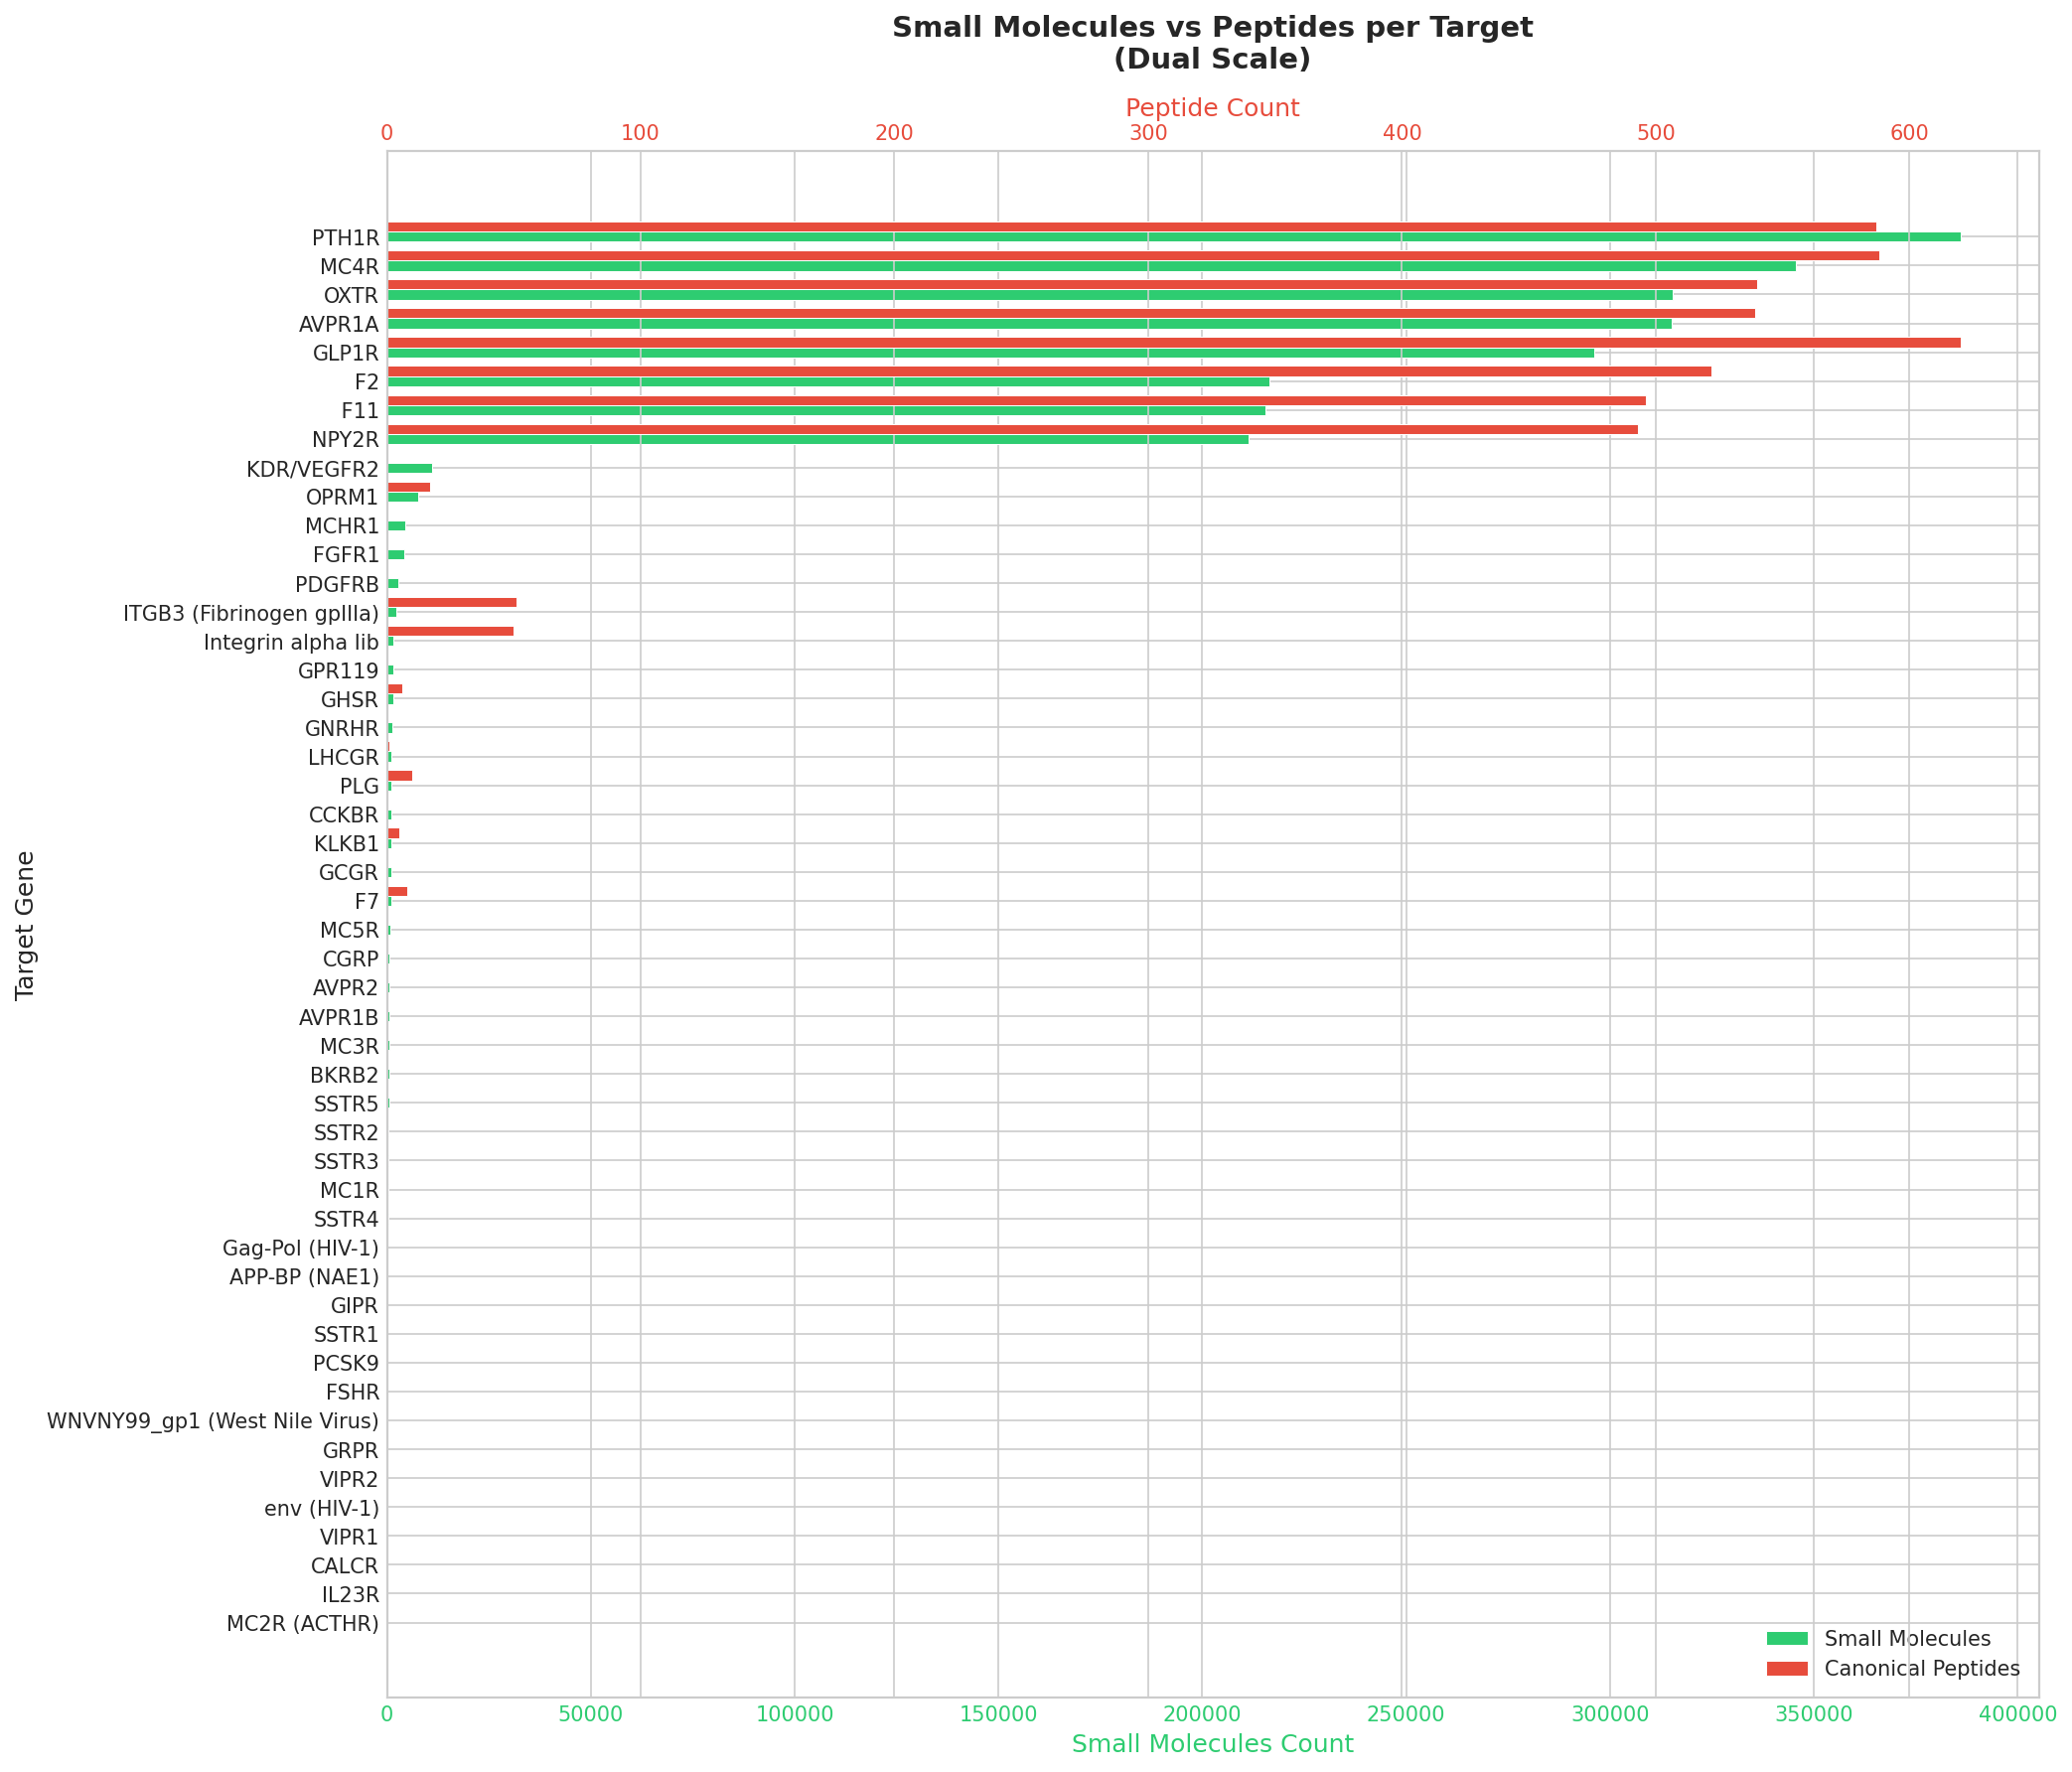


Fig 2: Molecule Type Composition (Full Dataset)
-----------------------------------------------


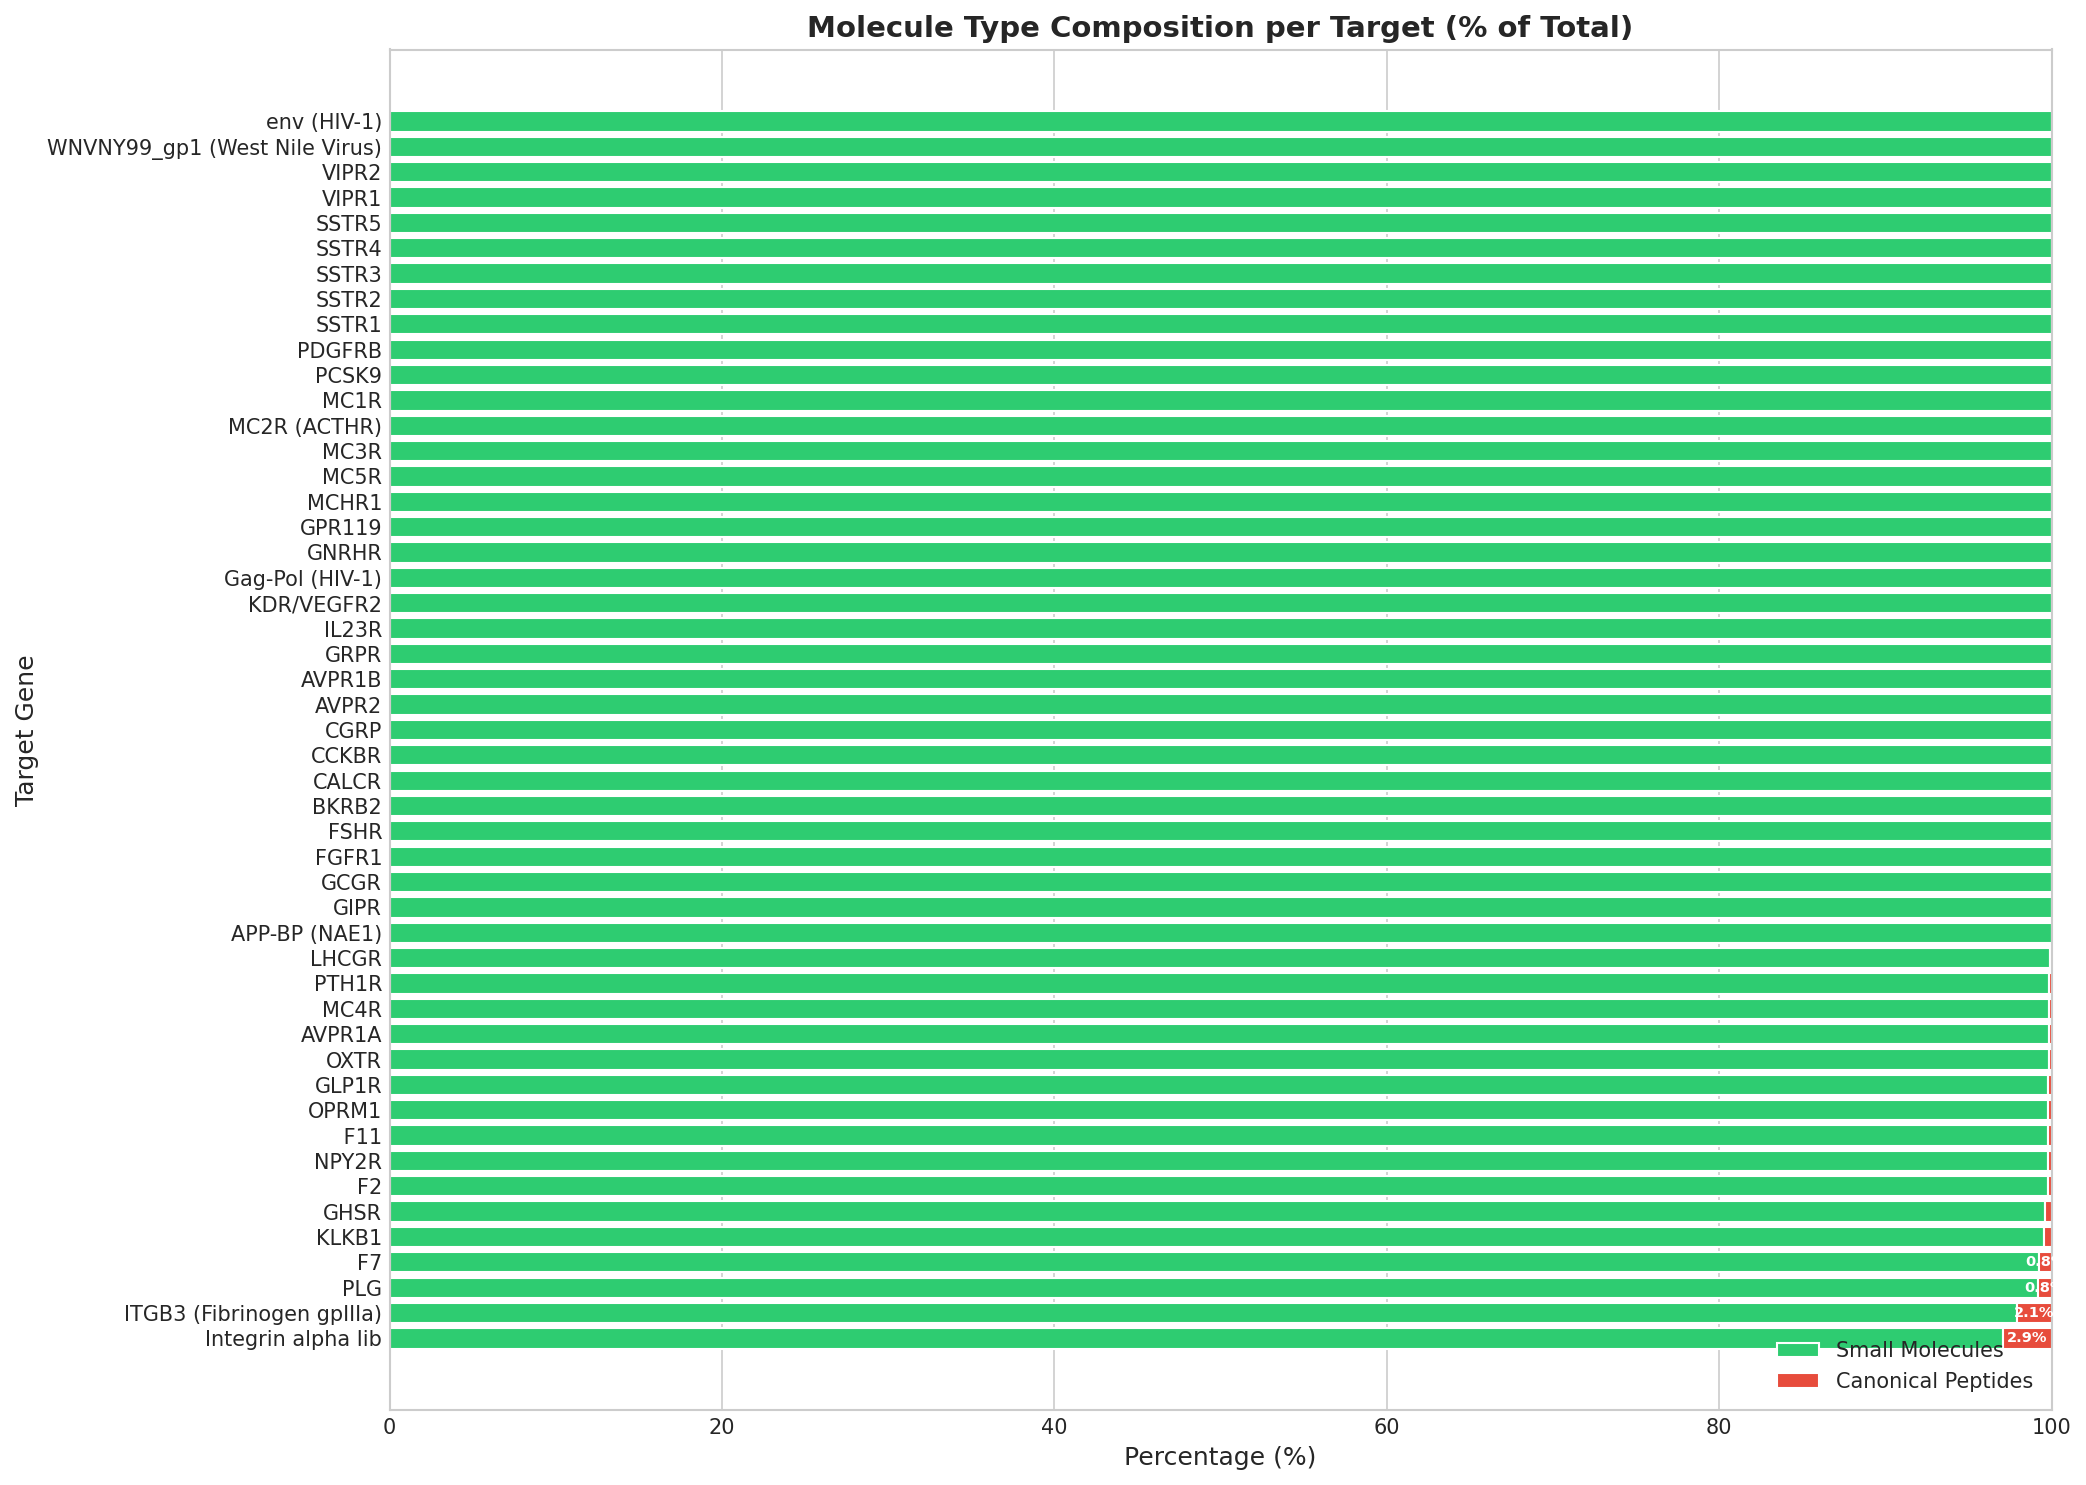


Fig 3: Average Peptide Backbone Length - SM (Full Dataset)
----------------------------------------------------------


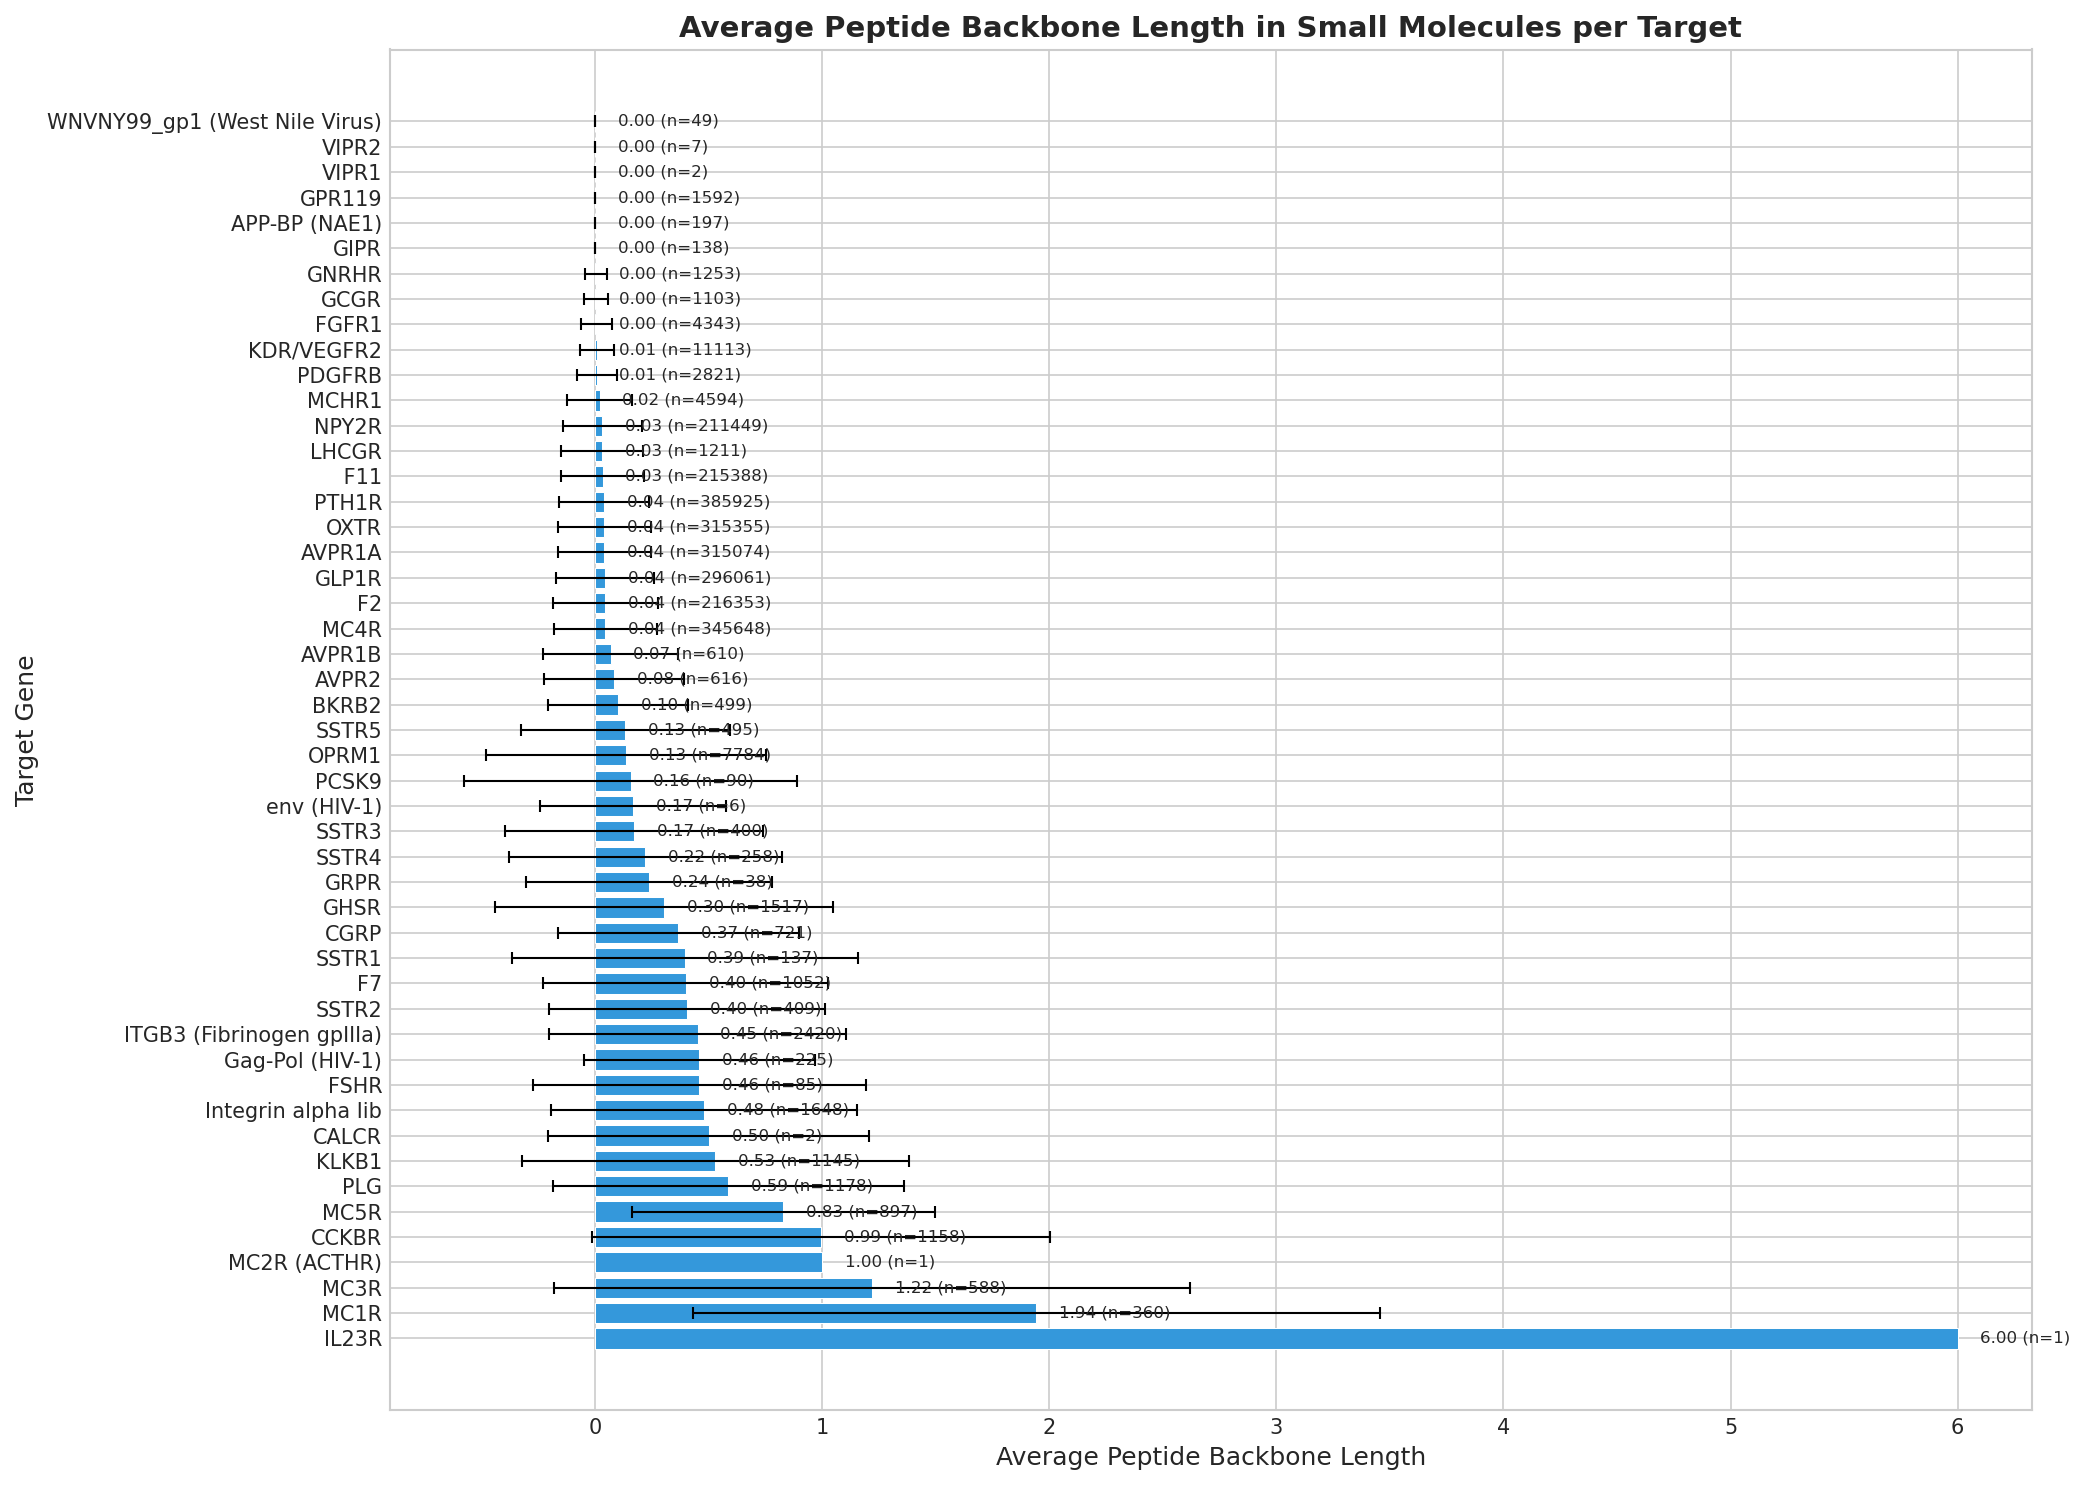


Fig 4: Average Peptide Bond Count - SM (Full Dataset)
-----------------------------------------------------


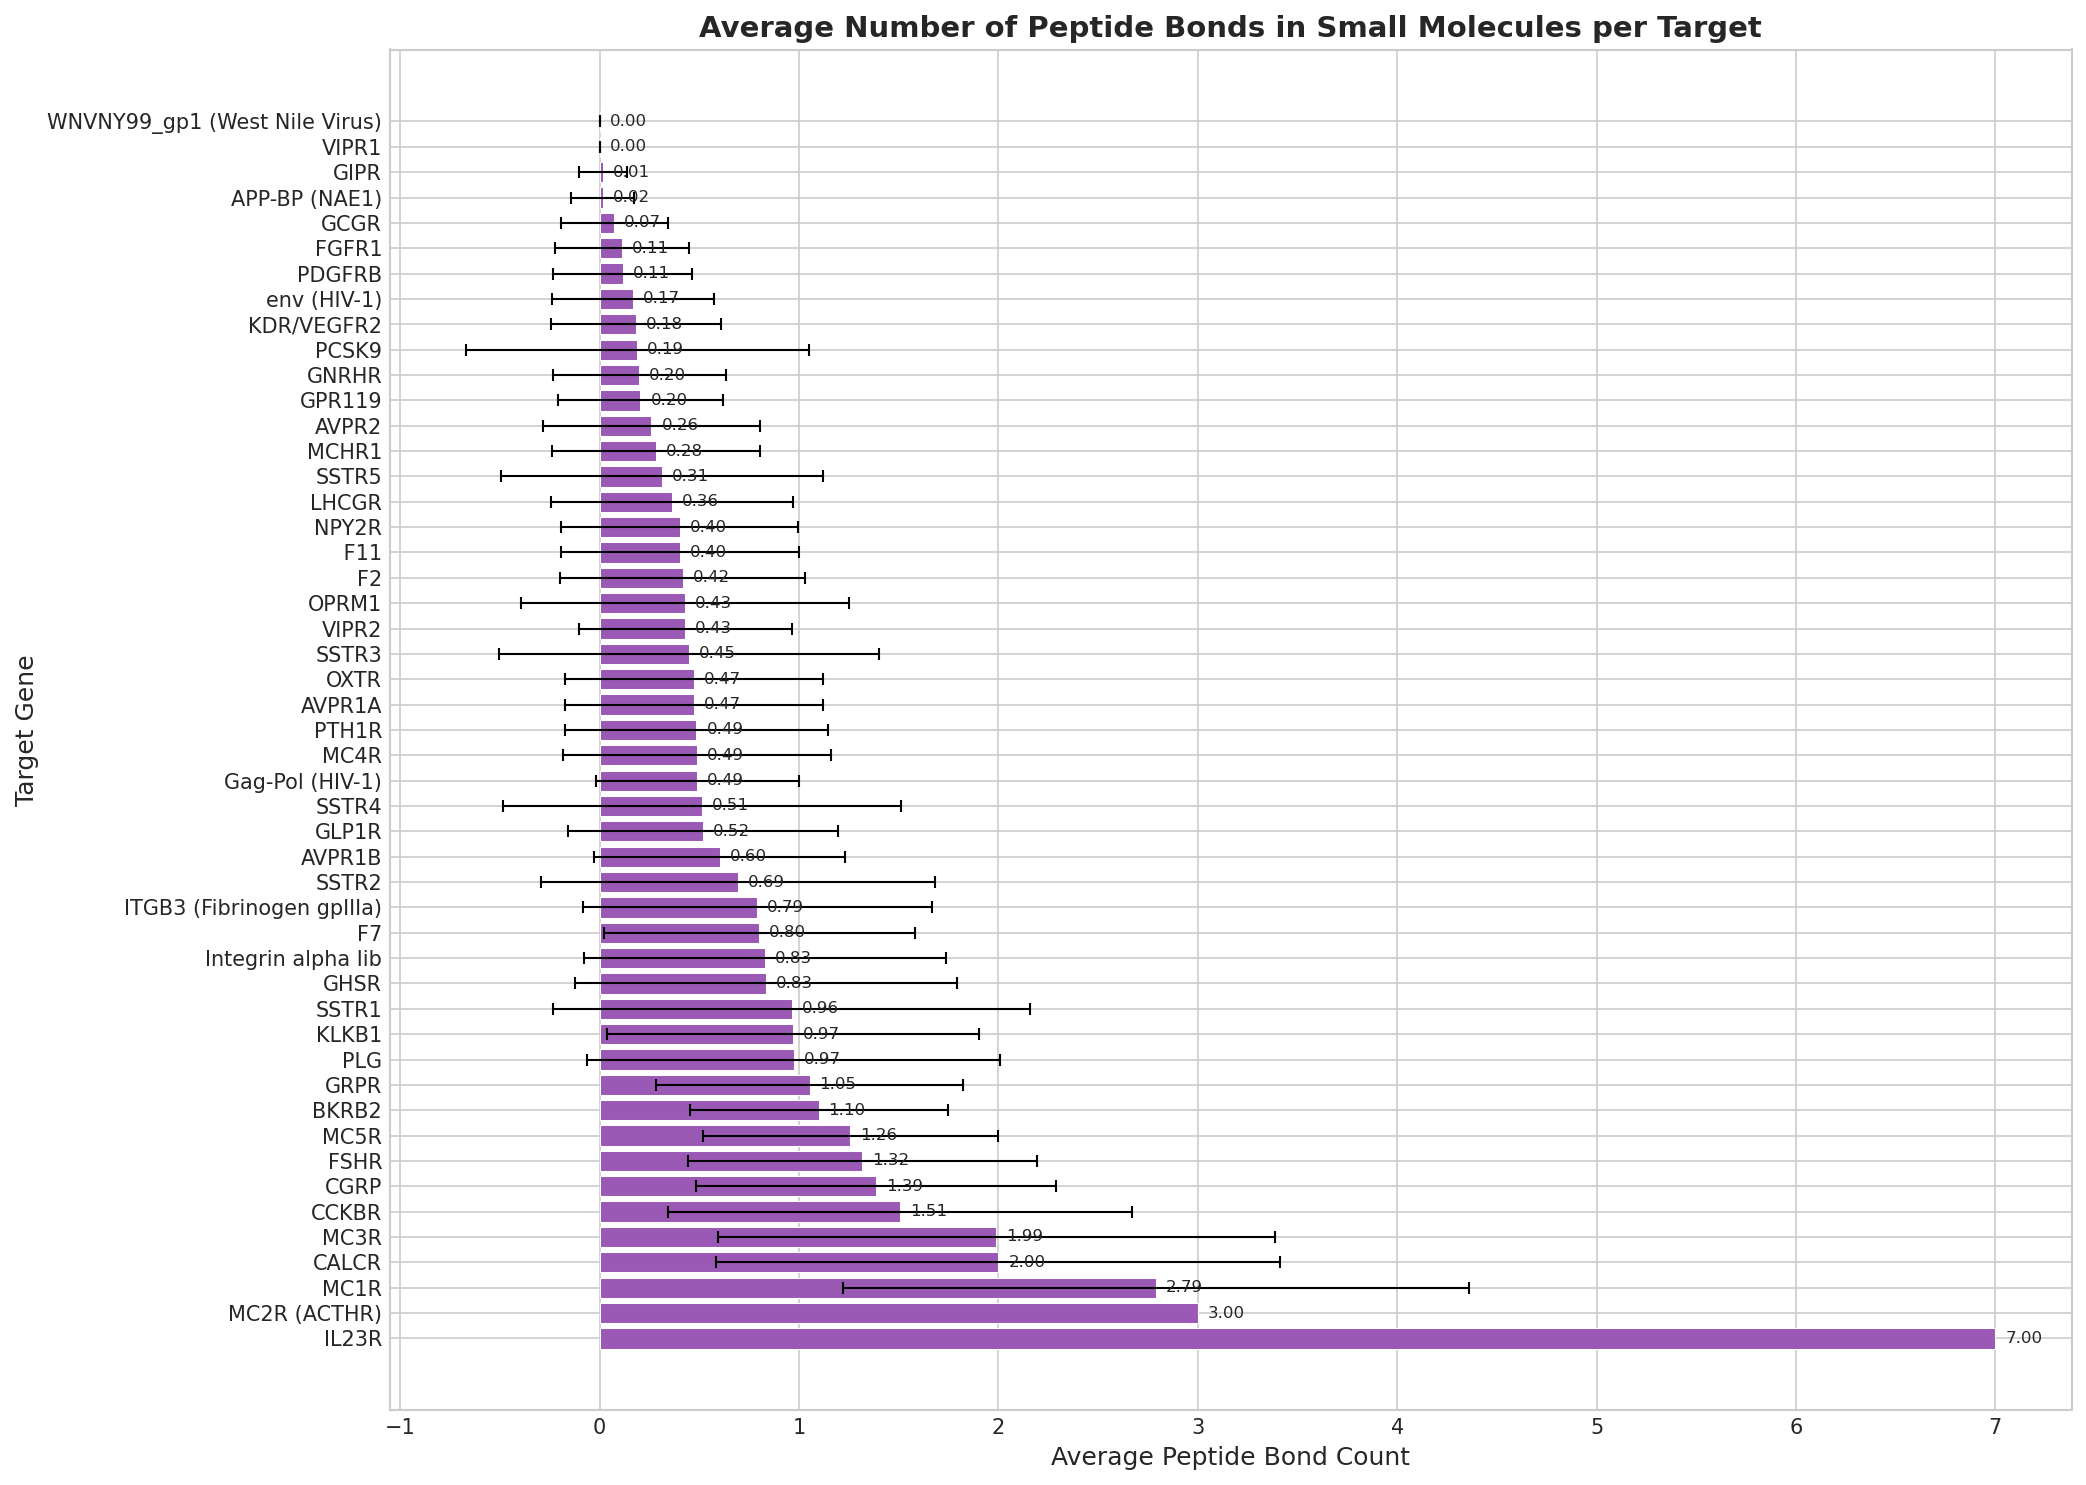


Fig 5: Small Molecules vs Peptides per Target (Activity Data)
-------------------------------------------------------------


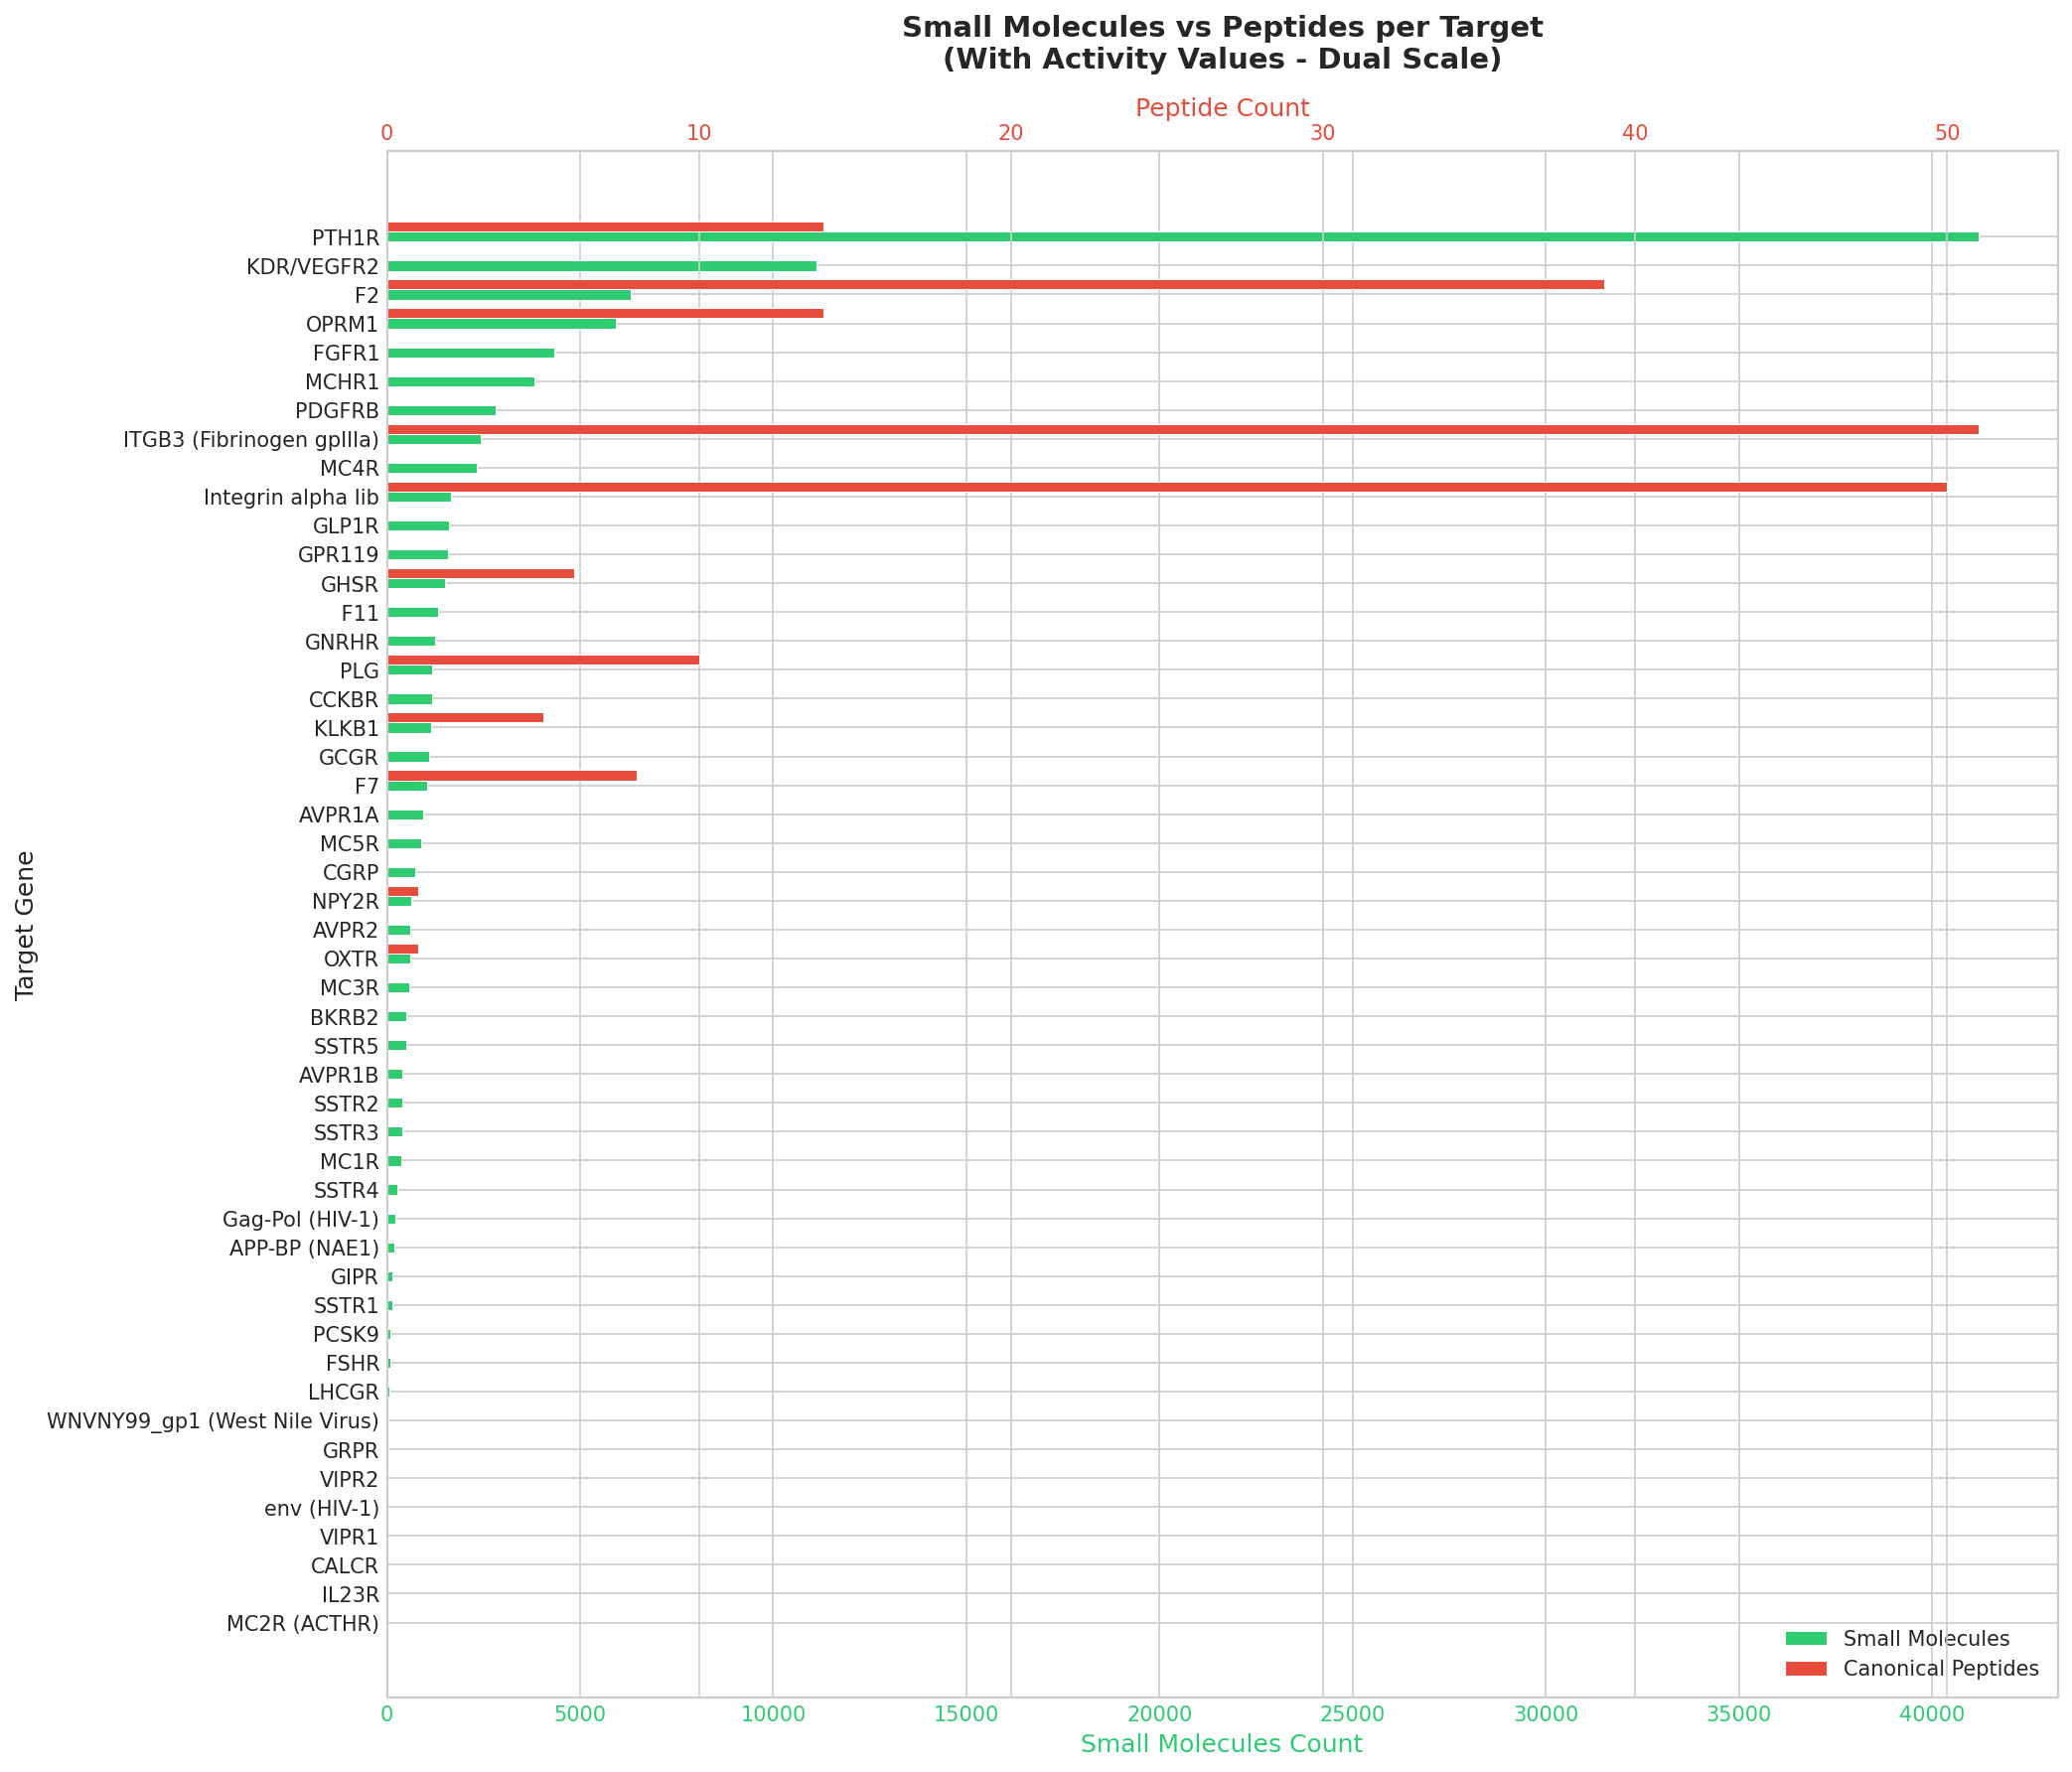


Fig 6: Molecule Type Composition (Activity Data)
------------------------------------------------


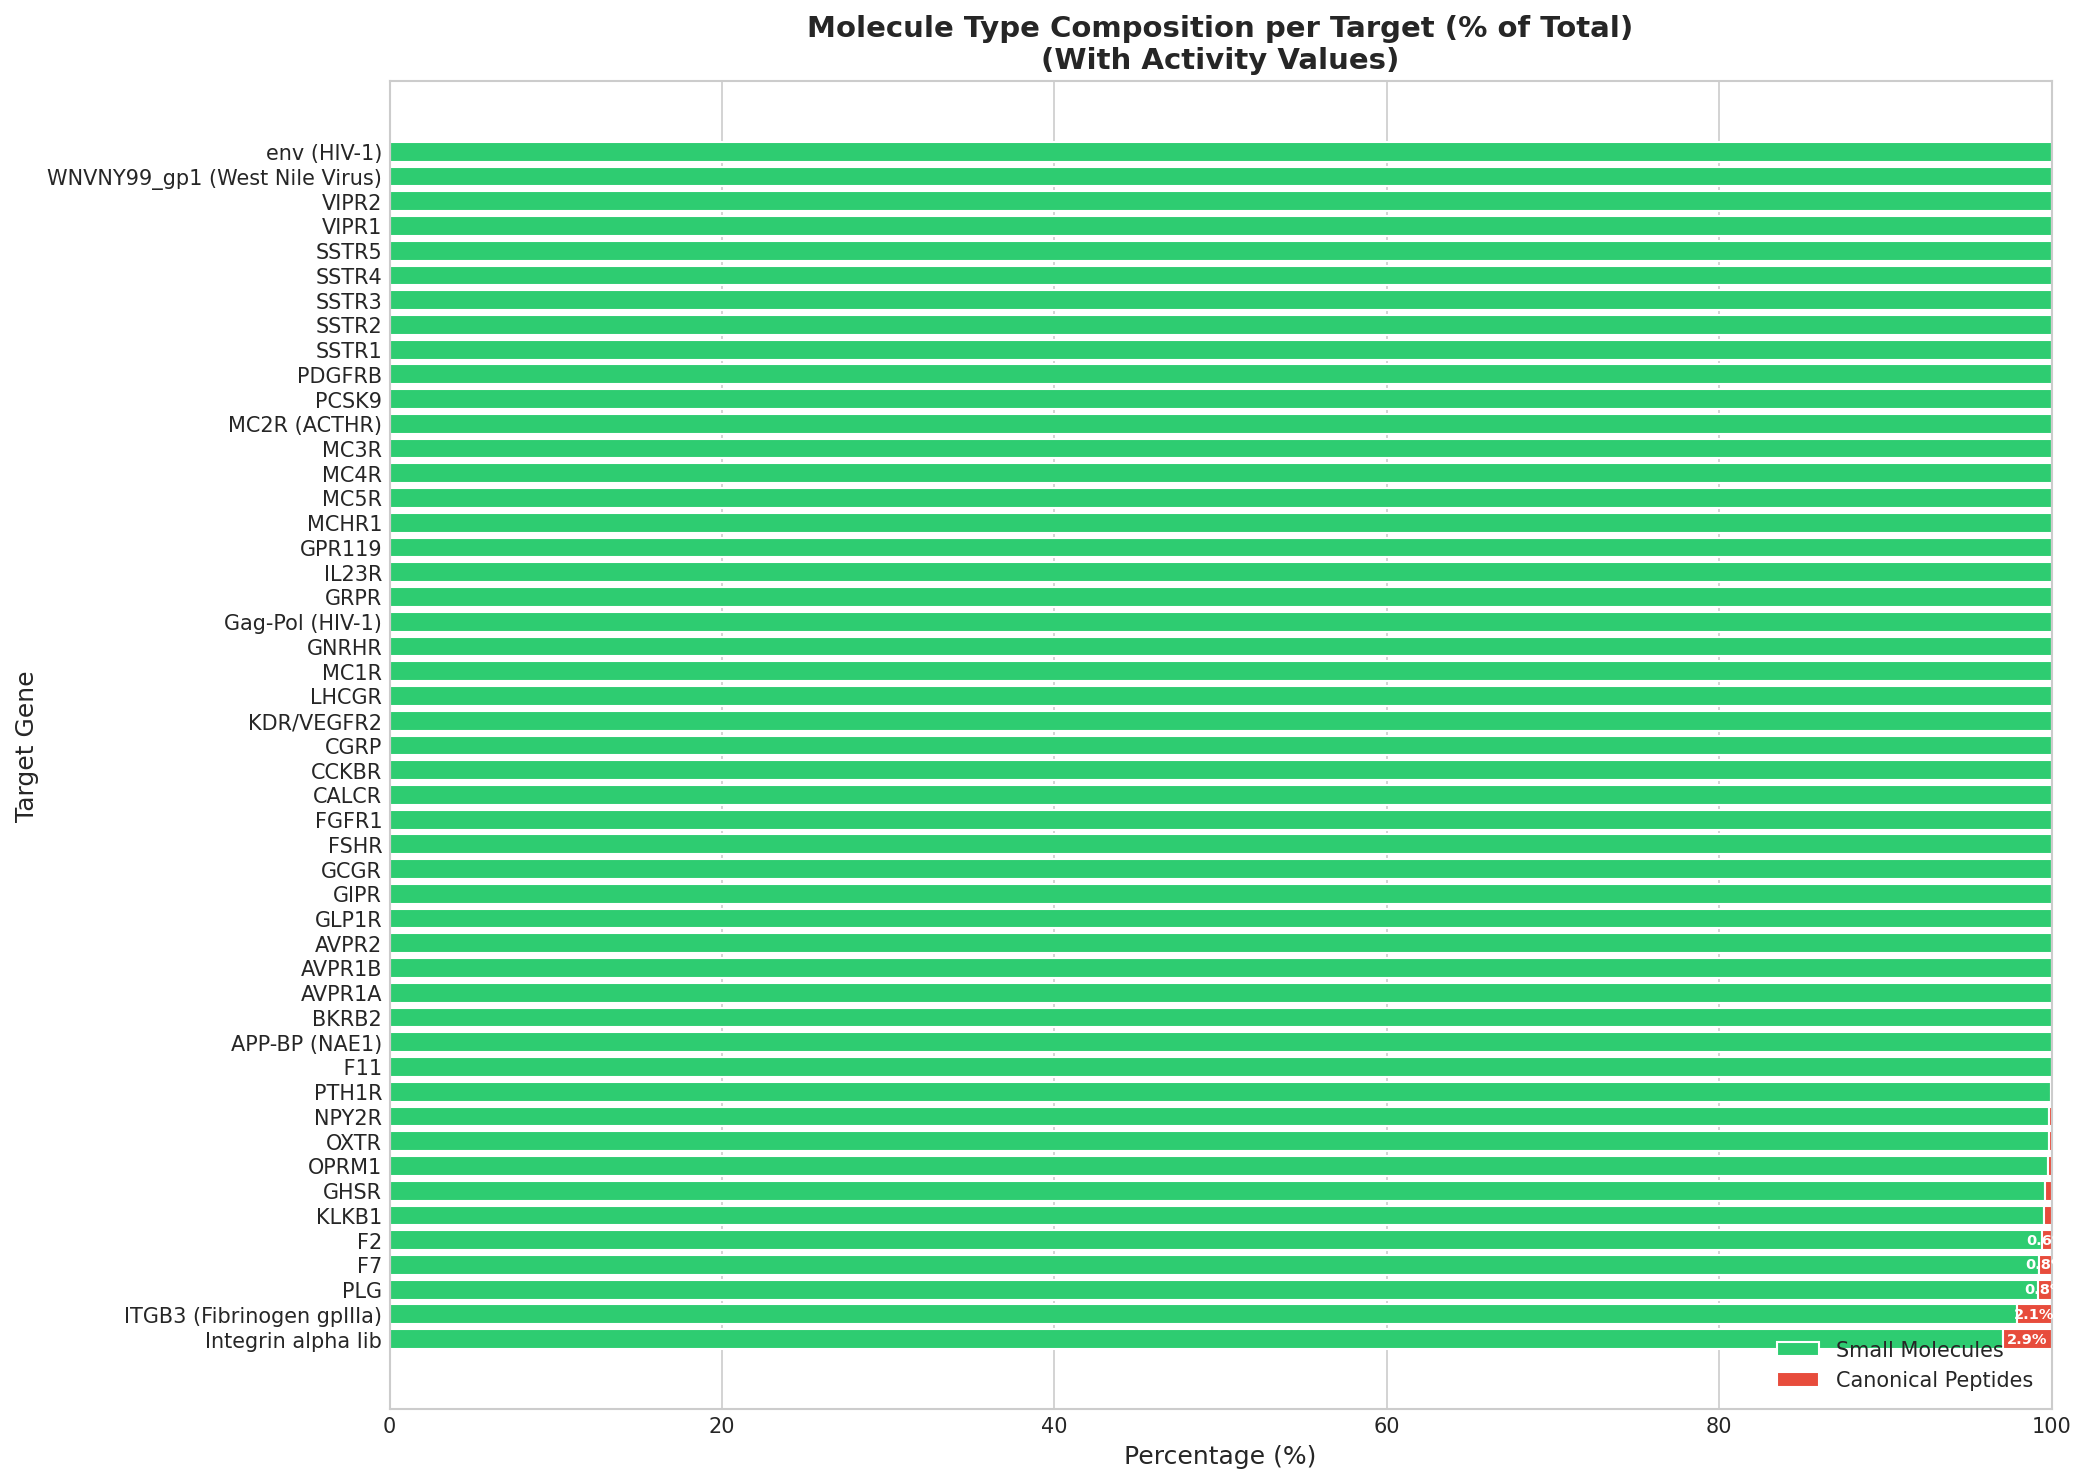


Fig 7: Average Peptide Backbone Length - SM (Activity Data)
-----------------------------------------------------------


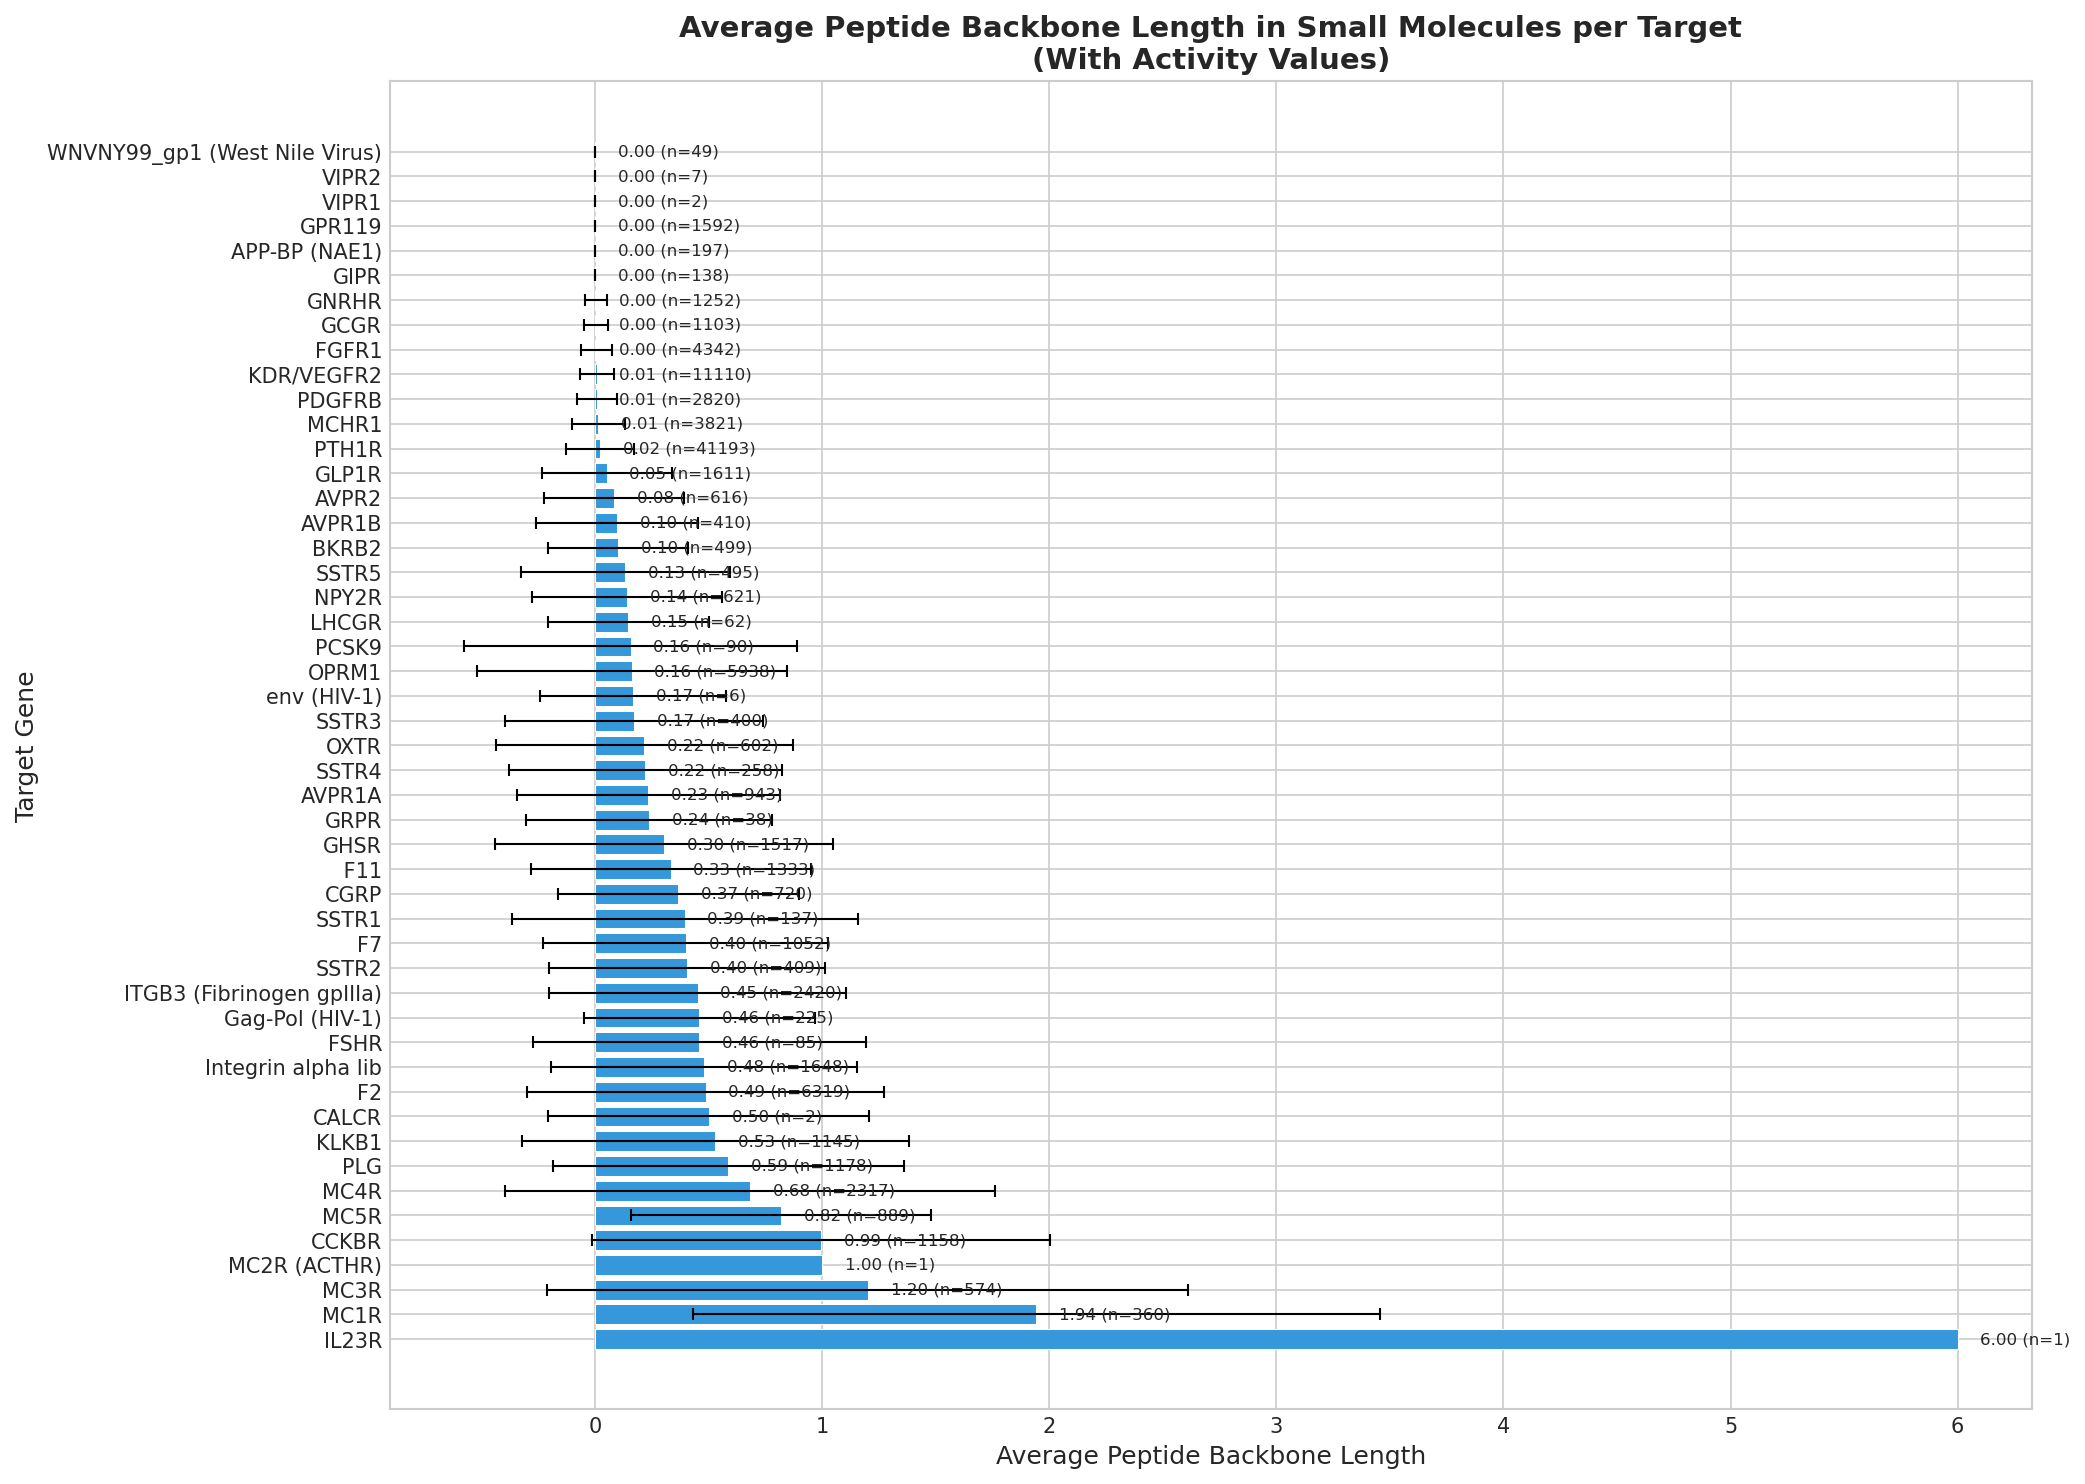


Fig 8: Average Peptide Bond Count - SM (Activity Data)
------------------------------------------------------


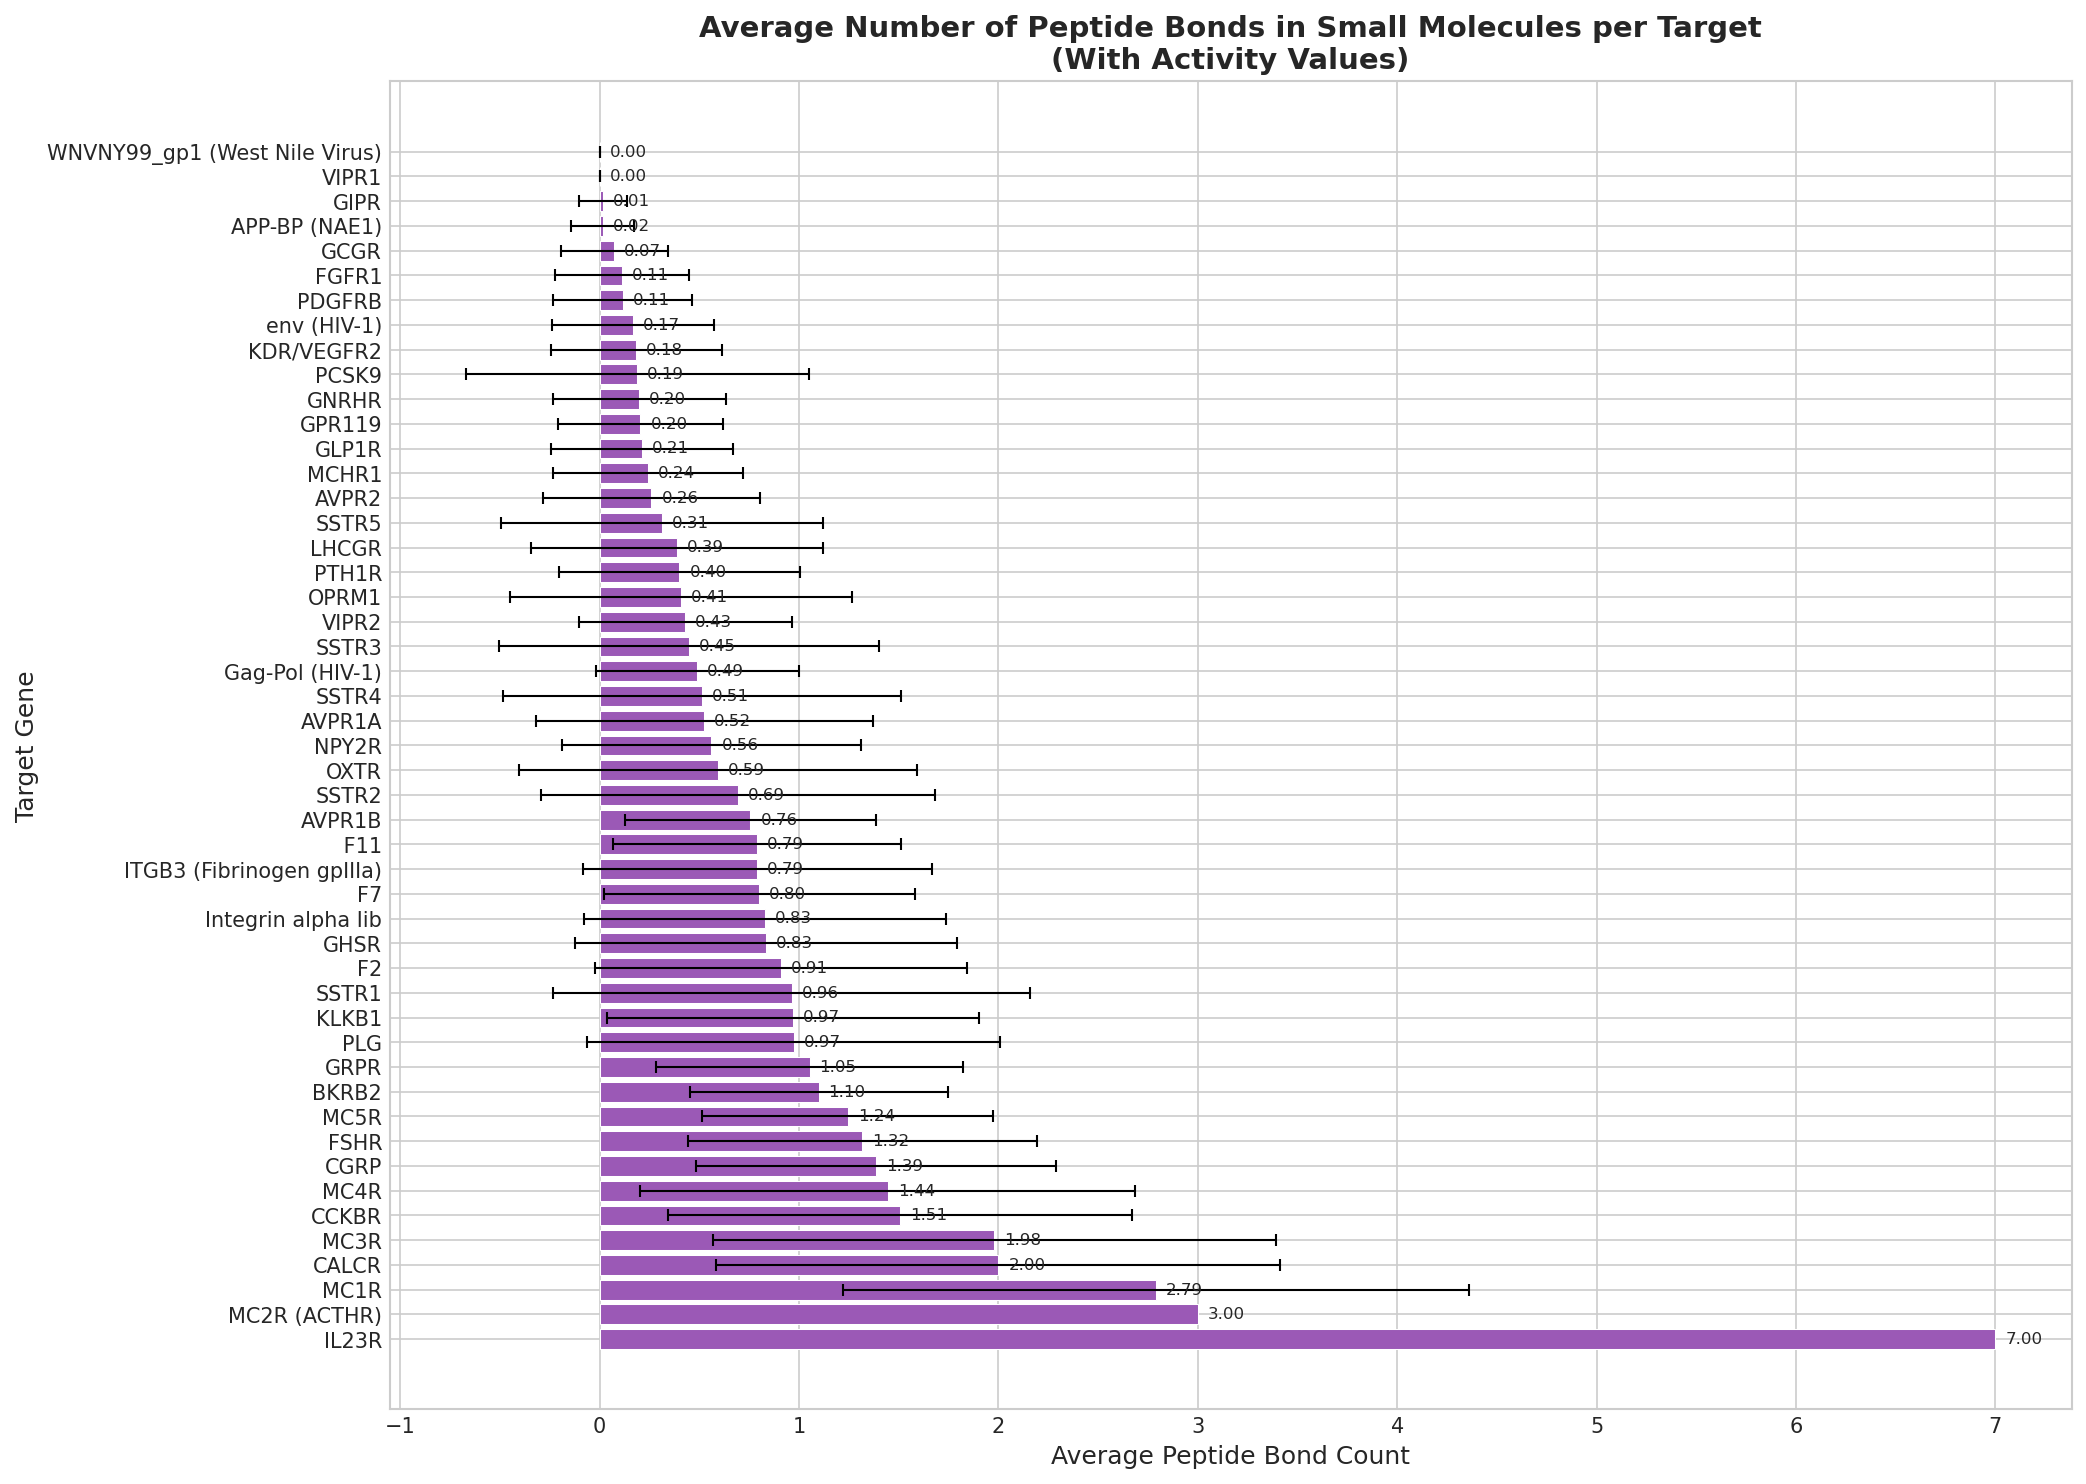

In [43]:
# =============================================================================
# Display All Generated Figures
# =============================================================================

from IPython.display import display, Image, HTML

# List of generated plots
plots = [
    ("plot_sm_vs_peptides_per_target.png", "Fig 1: Small Molecules vs Peptides per Target (Full Dataset)"),
    ("plot_molecule_composition_per_target.png", "Fig 2: Molecule Type Composition (Full Dataset)"),
    ("plot_avg_backbone_length_sm_per_target.png", "Fig 3: Average Peptide Backbone Length - SM (Full Dataset)"),
    ("plot_avg_peptide_bonds_sm_per_target.png", "Fig 4: Average Peptide Bond Count - SM (Full Dataset)"),
    ("plot_sm_vs_peptides_activity_data.png", "Fig 5: Small Molecules vs Peptides per Target (Activity Data)"),
    ("plot_molecule_composition_activity_data.png", "Fig 6: Molecule Type Composition (Activity Data)"),
    ("plot_avg_backbone_length_sm_activity_data.png", "Fig 7: Average Peptide Backbone Length - SM (Activity Data)"),
    ("plot_avg_peptide_bonds_sm_activity_data.png", "Fig 8: Average Peptide Bond Count - SM (Activity Data)"),
]

print("=" * 80)
print("GENERATED FIGURES SUMMARY")
print("=" * 80)

for filename, title in plots:
    filepath = f"{work_dir}/{filename}"
    if os.path.exists(filepath):
        print(f"\n{title}")
        print("-" * len(title))
        display(Image(filename=filepath, width=800))
    else:
        print(f"\n[Missing] {filename}")
